<a href="https://colab.research.google.com/github/ikraam05/dziri-sentiment-analysis/blob/main/notebooks/01_EDA_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets transformers accelerate evaluate imbalanced-learn
!pip install arabic-reshaper python-bidi wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 9.1 MB/s eta 0:00:00


In [ ]:
#import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from datasets import Dataset
import torch

In [ ]:
#dowlnload dziriBERT
tokenizer = AutoTokenizer.from_pretrained("alger-ia/dziribert")
model = AutoModel.from_pretrained("alger-ia/dziribert")




/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#load the dataset
dataset = load_dataset("arbml/Twifil")
dataset


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


data/train-00000-of-00001-eef2e32ea1bb4a(…):   0%|          | 0.00/699k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['ID', 'Code', 'Post', 'lang', 'Created At', 'Followers Count', 'Profile Link Color', 'Geo Enabled', 'Screen Name', 'Name', 'Profile Lang', 'Polarity', 'Polarity Class', 'User Age', 'Emotion', 'Platform'],
        num_rows: 6000
    })
})

In [ ]:
twifil = dataset["train"].to_pandas()
twifil.head()


,ID,Code,Post,lang,Created At,Followers Count,Profile Link Color,Geo Enabled,Screen Name,Name,Profile Lang,Polarity,Polarity Class,User Age,Emotion,Platform
0,1,9.5283479986508e+17,@gamehacker080 @WaellAmeer @Kempa2010 @omeralb...,ar,Mon Jan 15 09:28:13 +0000 2018,215,0084B4,1,JackoTyga,Amine Jacko,fr,"3,43",Positive,26.0,nan,Twitter
1,2,9.5283475039334e+17,@arar12332095361 صل الله عليه و سلم,ar,Mon Jan 15 09:28:01 +0000 2018,1682,19CF86,1,aminoooo_amine,Amine Bourahla,fr,"7,14",Positive,26.0,nan,Twitter
2,3,9.5283463826695e+17,@SRKFC1 @iamsrk @gaurikhan 💖💖💖💖💖💖 https://t.co...,und,Mon Jan 15 09:27:35 +0000 2018,114,1DA1F2,1,FoufaKiri,Foufa kiri,fr,"3,33",Positive,nan,nan,Twitter
3,4,9.5283457943348e+17,.@realDonaldTrump YOU did this you started it!...,en,Mon Jan 15 09:27:21 +0000 2018,5367,E81C4F,1,Spartanise,Spartanise,en,"-6,29",Negative,nan,nan,Twitter
4,5,9.5283405417663e+17,"وقال: "" ... وعليهم *أَنْ يكونوا على يقظةٍ* مِن...",ar,Mon Jan 15 09:25:15 +0000 2018,135,1DA1F2,1,GhanayK,أبو العباس كريم,ar,"-2,71",Negative,nan,nan,Twitter


In [ ]:
twifil.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  6000 non-null   object
 1   Code                6000 non-null   object
 2   Post                6000 non-null   object
 3   lang                6000 non-null   object
 4   Created At          6000 non-null   object
 5   Followers Count     6000 non-null   object
 6   Profile Link Color  6000 non-null   object
 7   Geo Enabled         6000 non-null   object
 8   Screen Name         6000 non-null   object
 9   Name                6000 non-null   object
 10  Profile Lang        6000 non-null   object
 11  Polarity            6000 non-null   object
 12  Polarity Class      6000 non-null   object
 13  User Age            6000 non-null   object
 14  Emotion             6000 non-null   object
 15  Platform            6000 non-null   object
dtypes: object(16)
memory usa

In [ ]:
#ETAPE 1 : Analyse Exploratoire du Corpus TWIFL

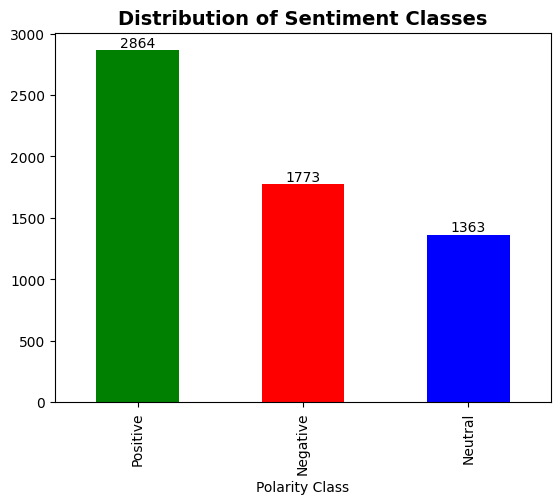

In [ ]:
class_counts = twifil["Polarity Class"].value_counts().plot(
    kind="bar"
)

# Define the colors
bar_colors = ['green', 'red', 'blue']

# Set the colors for each bar
for i, bar in enumerate(class_counts.patches):
    bar.set_facecolor(bar_colors[i % len(bar_colors)])

plt.title("Distribution of Sentiment Classes" , fontsize=14, fontweight='bold')
for container in class_counts.containers:
    class_counts.bar_label(container)

plt.show()

In [ ]:
# le ratio de déséquilibre
class_counts = twifil["Polarity Class"].value_counts()
ratio = class_counts.max() / class_counts.min()
ratio

2.1012472487160676

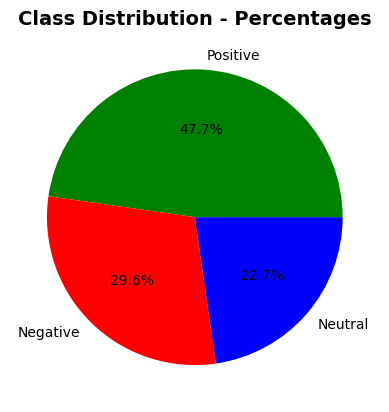

In [ ]:
#in percentage
# Pie Chart
twifil['Polarity Class'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['green','red','blue'])

plt.title("Class Distribution - Percentages",fontsize=14, fontweight="bold")
plt.ylabel('')
plt.show()

In [ ]:
twifil.to_csv("twifil_dataset.csv", index=False)


In [ ]:
!pip freeze > requirements.txt


In [ ]:
#1-2 :analyse linguistique de tweet

In [ ]:
#Vérifier les valeurs de la variable cible
twifil["Polarity Class"].unique()


array(['Positive', 'Negative', 'Neutral'], dtype=object)

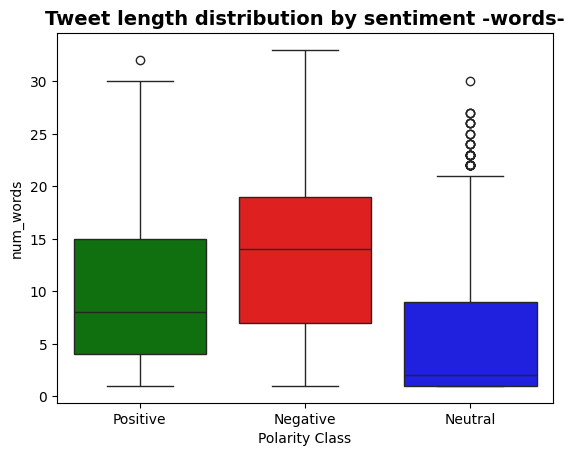

In [ ]:
#Distribution de la longueur des tweets en mots PAR CLASS
twifil["num_words"] = twifil["Post"].apply(lambda x: len(x.split()))
#visualisation by boxplot
sns.boxplot(data=twifil, x="Polarity Class", y="num_words", hue="Polarity Class", palette=['green','red','blue'], legend=False)
plt.title("Tweet length distribution by sentiment -words-", fontsize=14, fontweight='bold')
plt.show()

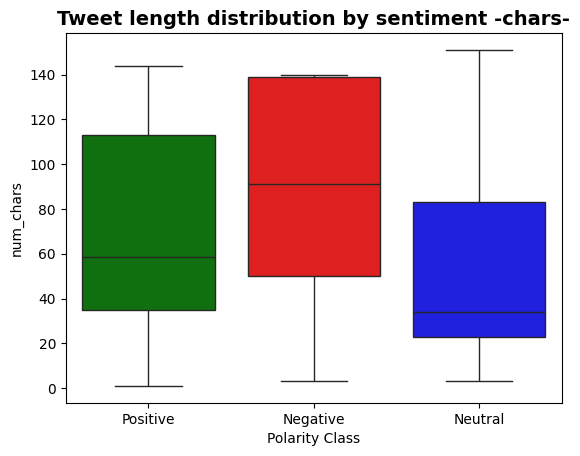

In [ ]:
#Distribution de la longueur des tweets en CARACTERE par class
twifil["num_chars"] = twifil["Post"].apply(len)
#visualisation by boxplot
sns.boxplot(data=twifil, x="Polarity Class", y="num_chars", hue="Polarity Class", palette=['green','red','blue'], legend=False)
plt.title("Tweet length distribution by sentiment -chars-" , fontsize=14, fontweight='bold')
plt.show()


In [ ]:

def detect_language(text):
    text = str(text).lower()

    arabic = bool(re.search(r'[\u0600-\u06FF]', text))
    latin = bool(re.search(r'[a-zA-Z]', text))

    arabizi = bool(re.search(r'[a-z]*[3579286][a-z]+', text))

    if arabic and latin:
        return "Code-switch"
    elif arabic:
        return "Arabic"
    elif arabizi and latin:
        return "Arabizi"
    elif latin:
        return "French/Latin"
    else:
        return "Other"
twifil["detected_lang"] = twifil["Post"].apply(detect_language)
lang_stats = twifil["detected_lang"].value_counts()

lang_table = pd.DataFrame({
    "Count": lang_stats,
    "Percentage": (lang_stats / len(twifil)) * 100
})

lang_table


,Count,Percentage
detected_lang,,
Code-switch,2300,38.333333
French/Latin,1915,31.916667
Arabizi,1512,25.200000
Arabic,257,4.283333
Other,16,0.266667


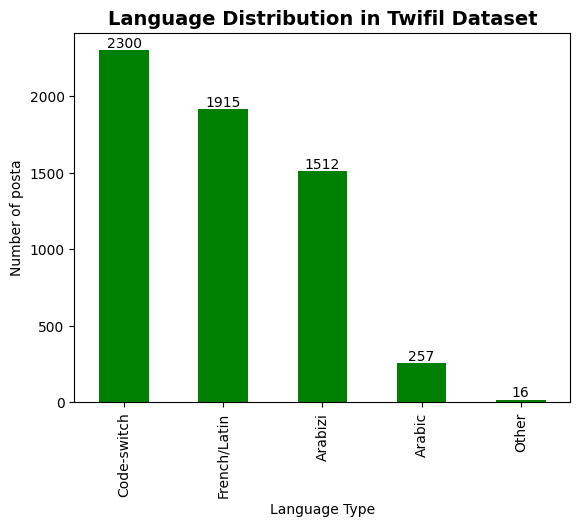

In [ ]:
#visualisation by bars
ax=twifil["detected_lang"].value_counts().plot(kind="bar",color="green")

plt.title("Language Distribution in Twifil Dataset",fontsize=14, fontweight='bold')
plt.ylabel("Number of posta")
plt.xlabel("Language Type")
for container in ax.containers:
    ax.bar_label(container)

plt.show()


In [ ]:
# langue by class tab
lang_by_sentiment = pd.crosstab(
    twifil["Polarity Class"],
    twifil["detected_lang"],
    margins=True
)

lang_by_sentiment


detected_lang,Arabic,Arabizi,Code-switch,French/Latin,Other,All
Polarity Class,,,,,,
Negative,113,312,844,501,3,1773
Neutral,11,660,219,468,5,1363
Positive,133,540,1237,946,8,2864
All,257,1512,2300,1915,16,6000


In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.3 MB/s eta 0:00:00


In [ ]:
#Proportion de tweets contenant des emojis
import emoji
twifil["has_emoji"] = twifil["Post"].apply(lambda x: any(char in emoji.EMOJI_DATA for char in str(x)))
emoji_stats = twifil.groupby("Polarity Class")["has_emoji"].agg([
    ("total by class", "sum"),
    ("percentage", lambda x: (x.sum() / len(x)) * 100)
])

total_row = pd.DataFrame({
    "total by class": [emoji_stats["total by class"].sum()],
    "percentage": [100.0]
}, index=["Total"])
emoji_stats = pd.concat([emoji_stats, total_row])
emoji_stats

,total by class,percentage
Negative,332,18.725324
Neutral,79,5.796038
Positive,863,30.132682
Total,1274,100.000000


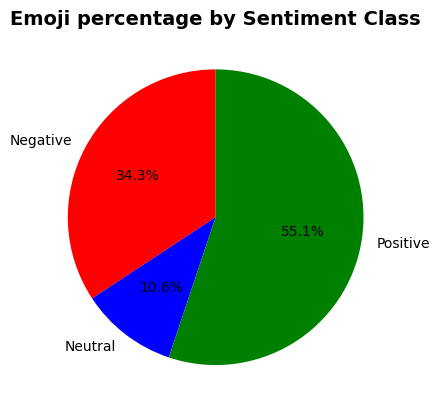

In [ ]:
#visualisation by pie char
plot_data = emoji_stats.drop("Total")

plot_data["percentage"].plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['red','blue','green']
)

plt.title("Emoji percentage by Sentiment Class", fontsize=14, fontweight="bold")
plt.ylabel('')
plt.show()


In [ ]:
#Proportion de tweets avec code-switching
def detect_code_switch(text):
    text = str(text) if pd.notna(text) else ""
    arabic = bool(re.search(r'[\u0600-\u06FF]', text))
    latin = bool(re.search(r'[a-zA-Z]', text))
    return arabic and latin
twifil["code_switch"] = twifil["Post"].apply(detect_code_switch)
twifil["code_switch"].value_counts()

# Get percentages
code_switch_pct = (twifil["code_switch"].sum() / len(twifil)) * 100
print(f"\nPercentage with code-switching: {code_switch_pct:.2f}%")

# Check by sentiment class
print("\nCode-switching by sentiment:")
code_switching = twifil.groupby("Polarity Class")["code_switch"].value_counts().unstack(fill_value=0)

#row total
code_switching["Total"] = code_switching.sum(axis=1)

# column total
total_row = pd.DataFrame(code_switching.sum()).T
total_row.index = ["Total"]
code_switching = pd.concat([code_switching, total_row])

code_switching



Percentage with code-switching: 38.33%

Code-switching by sentiment:


code_switch,False,True,Total
Negative,929,844,1773
Neutral,1144,219,1363
Positive,1627,1237,2864
Total,3700,2300,6000


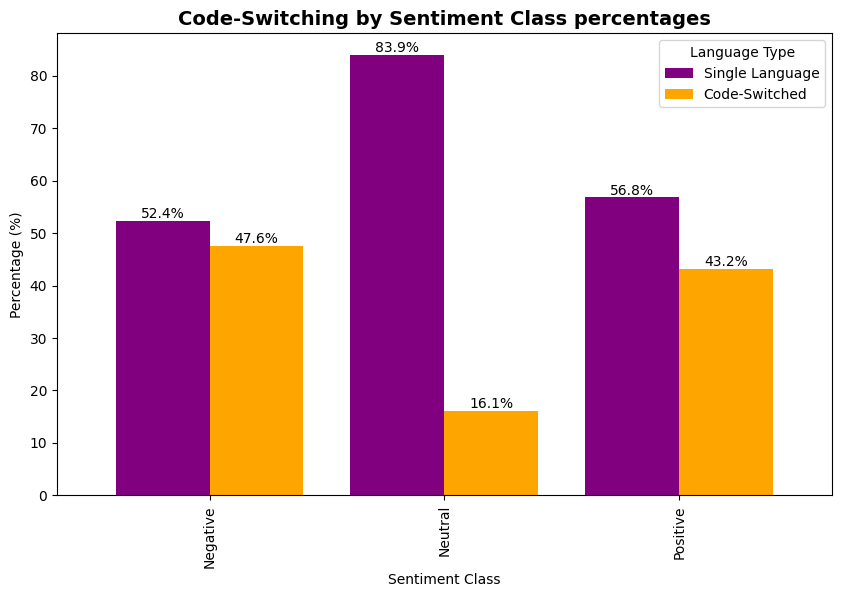

In [ ]:
# Create cross-tabulation
cross_tab = pd.crosstab(twifil["Polarity Class"], twifil["code_switch"],
                        normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
cross_tab.plot(kind='bar', ax=ax, color=['purple', 'orange'], width=0.8)

ax.set_title('Code-Switching by Sentiment Class percentages', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Percentage (%)')
ax.legend(['Single Language', 'Code-Switched'], title='Language Type')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

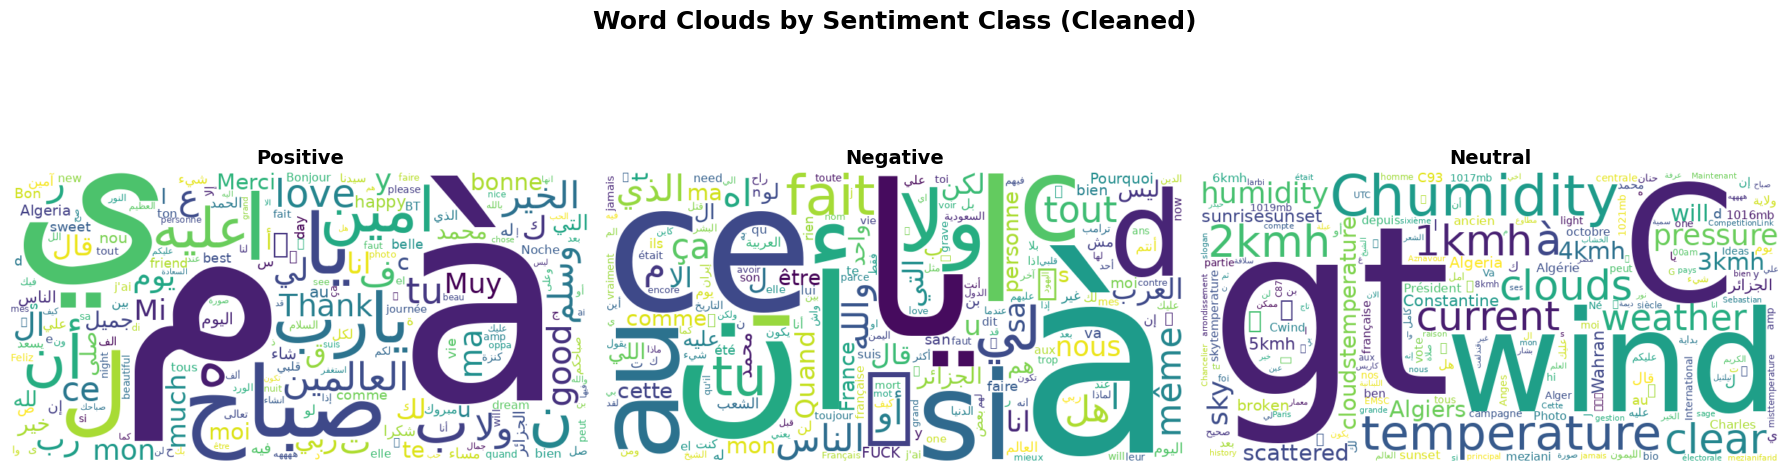

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import re

# ============================================================
# 1️⃣ Stopwords متعددة اللغات (IMPORTANT)
# ============================================================

# English stopwords (built-in)
stopwords = set(STOPWORDS)

# French stopwords
french_stopwords = {
    "le","la","les","de","des","du","un","une","et","ou","mais","vous","pour","à"
    "donc","car","ni","que","qui","quoi","est","sont","dans","a","il","je","se","si"
    "pour","avec","sur","pas","plus","moins","très","tres","ne","en","par","c'est",
    }

# Arabic stopwords (darija + classique)
arabic_stopwords = {
    "في","من","على","الى","إلى","عن","مع","هذا","هذه","ذلك","اللهم","صباح"
    "انا","انت","هو","هي","نحن","كان","ما","لا","نعم","كي","الله","حتى",
    "راهو","راهي","كانو","كون","باش","علاش","كيفاش","لم","ان","كل","و"
}

# Darija / Arabizi stopwords
darija_stopwords = {
    "ana","nta","nti","hna","kima","bch","rani","rah","rahom",
    "3la","fi","men","ela","wach","wesh","oui","non","saha",
    "kho","ya","lol","mdr","svp","stp","ok","gtc"
}

# دمج الكل
stopwords.update(french_stopwords)
stopwords.update(arabic_stopwords)
stopwords.update(darija_stopwords)

# ============================================================
# 2️⃣ WordCloud
# ============================================================

sentiments = twifil['Polarity Class'].unique()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, sentiment in enumerate(sentiments):
    sentiment_texts = twifil[twifil['Polarity Class'] == sentiment]['Post']

    all_text = ' '.join(sentiment_texts.astype(str))

    # تنظيف إضافي
    all_text = re.sub(r'http\S+|@\w+|#\w+', '', all_text)  # remove url, mention, hashtag
    all_text = re.sub(r'[\x00-\x1F\x7F\u200B-\u200F\uFEFF]', '', all_text)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=200,
        stopwords=stopwords,   # 🔥 هنا الإضافة المهمة
        font_path=font_path,
        colormap='viridis',
        collocations=False,
        random_state=42
    ).generate(all_text)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(sentiment, fontsize=14, fontweight='bold')

plt.suptitle('Word Clouds by Sentiment Class (Cleaned)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


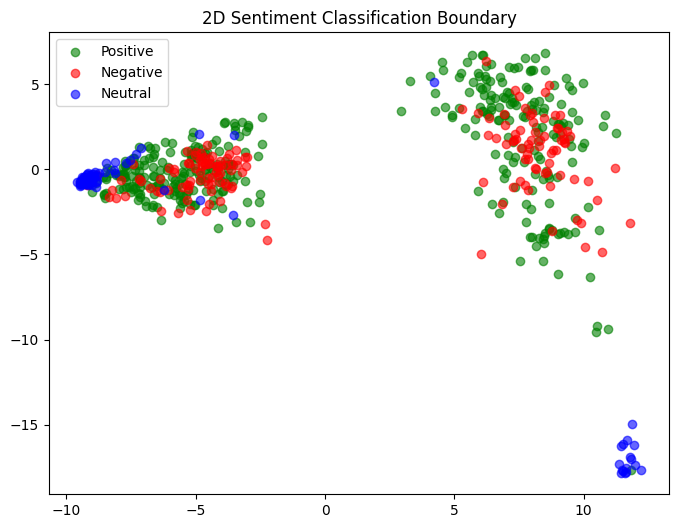

In [ ]:
# BERT embeddings AVANT prétraitement/rééquilibrage
tokenizer = AutoTokenizer.from_pretrained("alger-ia/dziribert")
model = AutoModel.from_pretrained("alger-ia/dziribert")

texts = twifil["Post"][:600]
labels = twifil["Polarity Class"][:600]

embeddings = []

for text in texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    with torch.no_grad():
        outputs = model(**inputs)

    cls = outputs.last_hidden_state[:,0,:].squeeze().numpy()
    embeddings.append(cls)

embeddings = np.array(embeddings)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X = pca.fit_transform(embeddings)
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X, labels)

import matplotlib.pyplot as plt

colors = {
    "Positive": "green",
    "Negative": "red",
    "Neutral": "blue"
}

plt.figure(figsize=(8,6))

for sentiment in colors:
    idx = labels == sentiment
    plt.scatter(
        X[idx,0],
        X[idx,1],
        c=colors[sentiment],
        label=sentiment,
        alpha=0.6
    )

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.title("2D Sentiment Classification Boundary")
plt.legend()
plt.show()


In [ ]:
  #tableau statistique

stats = twifil.groupby("Polarity Class").agg(
    nb_examples=("Post", "count"),
    avg_words=("Post", lambda x: x.str.split().apply(len).mean()),
    avg_characters=("Post", lambda x: x.str.len().mean())
)

stats["percentage"] = (stats["nb_examples"] / len(twifil)) * 100
total_row = pd.DataFrame({
    "nb_examples": [stats["nb_examples"].sum()],
    "avg_words": [stats["avg_words"].mean()],
    "avg_characters": [stats["avg_characters"].mean()],
    "percentage": [100.0]
}, index=["Total"])
stats = pd.concat([stats, total_row])
stats


,nb_examples,avg_words,avg_characters,percentage
Negative,1773,13.485618,89.973491,29.550000
Neutral,1363,5.680117,56.339692,22.716667
Positive,2864,9.886872,71.863478,47.733333
Total,6000,9.684202,72.725554,100.000000


In [ ]:
# ETAPE 2: PRETRAITEMNT
#netoyage de base

In [ ]:
twifil_copy = twifil.copy()

In [ ]:
# remove url
def remove_urls(text):
    return re.sub(r"http\S+|www\S+|https\S+", "", str(text))

twifil_copy["clean_text"] = twifil_copy["Post"].apply(remove_urls)


In [ ]:
#remove mention
def remove_mentions(text):
    return re.sub(r"@\w+", "", text)

twifil_copy["clean_text"] = twifil_copy["clean_text"].apply(remove_mentions)


In [ ]:
#convert emojies
def convert_emojis(text):
    return emoji.demojize(text)

twifil_copy["clean_text"] = twifil_copy["clean_text"].apply(convert_emojis)


In [ ]:
# supprimer les doublants
twifil_copy= twifil_copy.drop_duplicates(subset=["clean_text"])


In [ ]:
#supprimer les tweet vides
twifil_copy = twifil_copy[twifil_copy["clean_text"].str.strip() != ""]
#supprimer nan
twifil_copy = twifil_copy[twifil_copy["clean_text"].notna()]
#supprimer inutile text
twifil_copy["clean_text"] = twifil_copy["clean_text"].str.strip()
def is_useful_text(text):
    """
    Vérifie si un texte contient du contenu utile pour l'analyse de sentiment
    Garde les tweets avec emojis car ils expriment des émotions
     # si le texte est vide ou sans contenu significatif il retourne false
    """
    if pd.isna(text):
        return False

    text = str(text).strip()

    if text == "":
        return False

    # Compter les emojis convertis
    emoji_pattern = re.compile(r':[a-z_]+:')
    emojis = emoji_pattern.findall(text)

    # Enlever les emojis pour vérifier le reste du texte
    text_without_emoji = emoji_pattern.sub('', text)
    text_without_emoji = text_without_emoji.strip()

    # Enlever les chiffres et ponctuations pour ne garder que les mots
    words_only = re.sub(r'[\d\W_]+', ' ', text_without_emoji)
    words_only = ' '.join(words_only.split())

    # Garder le tweet si:
    # - Il a au moins un mot (même court) OU
    # - Il a au moins un emoji
    has_words = len(words_only) > 1
    has_emojis = len(emojis) >= 1

    return has_words or has_emojis
twifil_copy = twifil_copy[twifil_copy["clean_text"].apply(is_useful_text)]


In [ ]:
#2.2 Normalisation spécifique au darija

In [ ]:
def normalize_repeated_letters(text):
    # Arabic letters repetition
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    return text

twifil_copy["clean_text"] = twifil_copy["clean_text"].apply(normalize_repeated_letters)


In [ ]:
def normalize_numbers(text):
    eastern_to_western = str.maketrans(
        "٠١٢٣٤٥٦٧٨٩",
        "0123456789"
    )
    return text.translate(eastern_to_western)

twifil_copy["clean_text"] = twifil_copy["clean_text"].apply(normalize_numbers)


In [ ]:
# amelioration en plus

In [ ]:
# remove hashtag
def normalize_hashtags(text):
        text = re.sub(r'#(\w+)', r'\1', text)
        return text
twifil_copy["clean_text"] = twifil_copy["clean_text"].apply(normalize_hashtags)


In [ ]:
    #Supprimer les caractères de contrôle et autres caractères non imprimables
def remove_non_printable(text):
       text = ''.join(char for char in text if char.isprintable())
       return text
twifil_copy["clean_text"] = twifil_copy["clean_text"].apply(remove_non_printable)


In [ ]:
  #  Supprimer les chaînes de caractères sans valeur sentimentale
def clean_noise_strings(text):
    if pd.isna(text):
        return text

    text = str(text)

    # 1. Supprimer les hashs(32, 40, 64 caractères hexadécimaux)
    text = re.sub(r'\b[0-9a-f]{32}\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\b[0-9a-f]{40}\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\b[0-9a-f]{64}\b', '', text, flags=re.IGNORECASE)

    # 2. Supprimer les UUID
    uuid_pattern = r'\b[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}\b'
    text = re.sub(uuid_pattern, '', text, flags=re.IGNORECASE)

    # 3. Supprimer les chaînes qui ressemblent à des tokens techniques
    # (mélange de lettres, chiffres, underscores, points)
    text = re.sub(r'\b[a-zA-Z0-9._]{25,}\b', '', text)

    # 4. Supprimer les chaînes qui n'ont pas de voyelles (probablement du bruit)
    # On applique seulement sur les chaînes > 15 caractères
    def has_vowels(word):
        return bool(re.search(r'[aeiouAEIOU]', word))

    words = text.split()
    filtered_words = []
    for word in words:
        # Garder si: court (<15) OU a des voyelles OU a de l'arabe
        if len(word) < 15 or has_vowels(word) or re.search(r'[\u0600-\u06FF]', word):
            filtered_words.append(word)

    text = ' '.join(filtered_words)

    # 5. Nettoyer les espaces
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    return text
twifil_copy["clean_text"] = twifil_copy["clean_text"].apply(clean_noise_strings)


In [ ]:
#normalize repeated emojis
def normalize_repeated_emojis(text):

    if pd.isna(text):
        return text

    text = str(text)

    emoji_pattern = r'(:[a-z_]+:)\1+'

    def replace_with_count(match):
        emoji = match.group(1)
        full_match = match.group(0)
        count = full_match.count(emoji)

        if count > 1:
            return f"{emoji}_x{count}"
        return emoji

    text = re.sub(emoji_pattern, replace_with_count, text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    return text
twifil_copy["clean_text"]= twifil_copy["clean_text"].apply(normalize_repeated_emojis)

In [ ]:

twifil_copy[["Post", "clean_text"]].sample(10)


,Post,clean_text
3470,@MOU_st6 يا اخي جمال محترم يلزم نتعلم كل واحد ...,يا اخي جمال محترم يلزم نتعلم كل واحد يعطي رايه...
656,@davidbisbal @Twitter Felicidades Gran Artista...,Felicidades Gran Artista Te Lo Mereces :thumbs...
5789,@kasimf انها الاستخبارات الامريكية,انها الاستخبارات الامريكية
5342,"Ne vous attachez jamais trop à quelqu'un, sauf...","Ne vous attachez jamais trop à quelqu'un, sauf..."
3430,Hazaaaaaaard ✌\n#CHELIV,Hazaard :victory_hand:CHELIV
1861,😍🤣,:smiling_face_with_heart-eyes:::
325,just ate a 12 pack of sausages massive protein...,just ate a 12 pack of sausages massive protein...
4441,@DoctorNene Now here in Algeria 🇩🇿 city tiziou...,Now here in Algeria :Algeria: city tiziouzou i...
3971,@Sindrilla7 و ان تعدوا نعمة الله لا تحصوها \nو...,و ان تعدوا نعمة الله لا تحصوها و ان نرضى بما ق...
1546,@BlackPinkyWho @livemalikhadid @gossipseriesfr...,Bonjour


In [ ]:
und_tweets = twifil_copy[twifil_copy["lang"] == "und"]
print("Number of 'und' tweets:", len(und_tweets))
und_tweets["clean_text"].sample(10)


Number of 'und' tweets: 378


,clean_text
2902,:slightly_smiling_face:_x10
3361,":globe_showing_Asia-Australia: (23.906585, 1.7..."
4180,صور | 180930شينبي في برنامج King Of Masked Sin...
869,souhilaBenLachhab souhilabenlachhab
1732,Wow
338,Mag: 3.4 - Depth: 10 km - UTC 10:05 AM - North...
5058,RIP
4147,:smiling_face_with_heart-eyes:
2098,:red_heart:_x2:Canada::Canada::red_heart:_x2
113,hh


In [ ]:
und_analysis = und_tweets["detected_lang"].value_counts()
und_analysis


,count
detected_lang,
French/Latin,195
Arabizi,109
Code-switch,64
Other,8
Arabic,2


In [ ]:
# tweet len
twifil_copy["tweet_length"] = twifil_copy["clean_text"].apply(lambda x: len(str(x).split()))
short_tweets = twifil_copy[twifil_copy["tweet_length"] <= 2]

print("Number of very short tweets:", len(short_tweets))
print("Percentage:", (len(short_tweets) / len(twifil_copy)) * 100)


Number of very short tweets: 842
Percentage: 16.90084303492573


In [ ]:
#short tweets par class
sentiment_counts =short_tweets["Polarity Class"].value_counts()
sentiment_counts

,count
Polarity Class,
Positive,530
Neutral,183
Negative,129


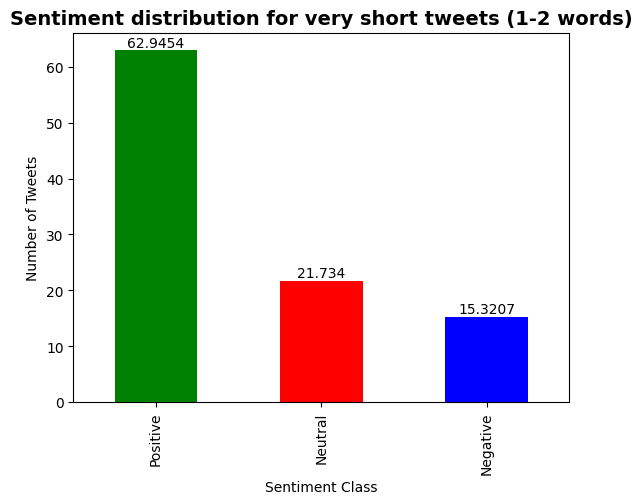

In [ ]:
#visualisation by barchar
sentiment_percentage = short_tweets["Polarity Class"].value_counts(normalize=True) * 100

ax=sentiment_percentage.plot(kind="bar")
# Define the colors
bar_colors = ['green', 'red', 'blue']

# Set the colors for each bar
for i, bar in enumerate(ax.patches):
    bar.set_facecolor(bar_colors[i % len(bar_colors)])
plt.title("Sentiment distribution for very short tweets (1-2 words)" ,fontsize=14 , fontweight="bold")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Tweets")
for container in ax.containers:
    ax.bar_label(container)
plt.show()


In [ ]:
twifil_copy.shape

(4982, 23)

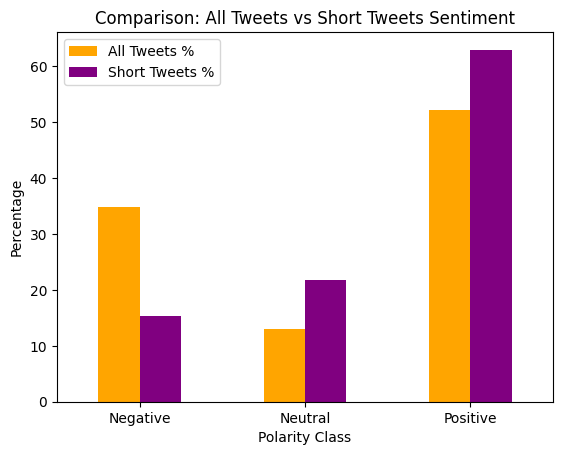

In [ ]:
#comparaison between short and all tweets
all_counts = twifil_copy["Polarity Class"].value_counts(normalize=True) * 100
short_counts = short_tweets["Polarity Class"].value_counts(normalize=True) * 100

comparison = pd.DataFrame({
    "All Tweets %": all_counts,
    "Short Tweets %": short_counts
})

comparison.plot(kind="bar", color=['orange','purple'])
plt.title("Comparison: All Tweets vs Short Tweets Sentiment")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()


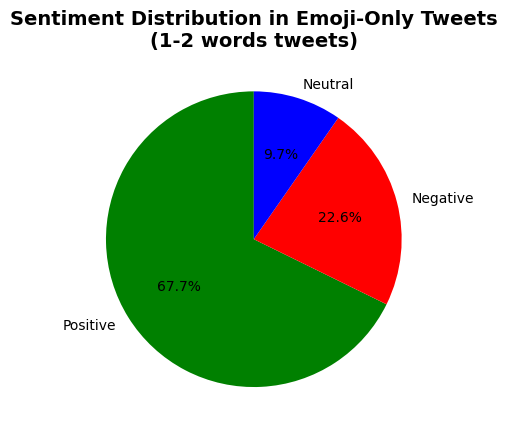


Statistiques des tweets avec seulement des emojis:
Nombre total: 31


In [ ]:
#visualisation des short tweets that has only emojies
# Identifier les tweets avec seulement des emojis
def has_only_emojis(text):
    if pd.isna(text):
        return False
    text = str(text).strip()
    emoji_pattern = re.compile(r'^(:[a-z_]+:\s*)+$')
    return bool(emoji_pattern.match(text))

emoji_only_tweets = twifil_copy[twifil_copy["clean_text"].apply(has_only_emojis)]

# Pie chart
if len(emoji_only_tweets) > 0:
    emoji_sentiment = emoji_only_tweets["Polarity Class"].value_counts(normalize=True) * 100

    wedges, texts, autotexts = plt.pie(
        emoji_sentiment.values,
        labels=emoji_sentiment.index,
        colors=['green', 'red', 'blue'],
        autopct='%1.1f%%',
        startangle=90,
    )

    plt.title("Sentiment Distribution in Emoji-Only Tweets\n(1-2 words tweets)",
              fontsize=14, fontweight="bold")
    plt.show()

    # Afficher les statistiques
    print("\nStatistiques des tweets avec seulement des emojis:")
    print(f"Nombre total: {len(emoji_only_tweets)}")


In [ ]:
#verifier l'absebce des val innatendues
twifil_copy["Polarity Class"].value_counts()


,count
Polarity Class,
Positive,2596
Negative,1736
Neutral,650


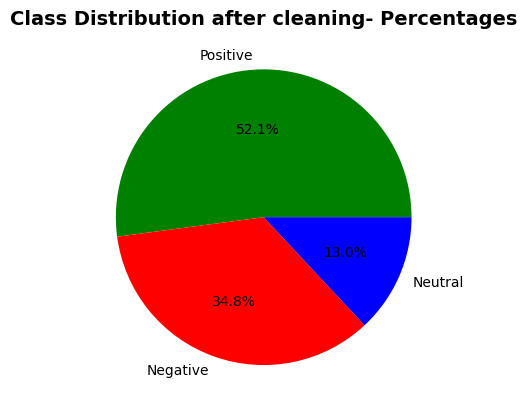

In [ ]:
# Pie Chart
twifil_copy['Polarity Class'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['green','red','blue'])

plt.title("Class Distribution after cleaning- Percentages",fontsize=14, fontweight="bold")
plt.ylabel('')
plt.show()

In [ ]:
#etape 3 : split

In [ ]:

from sklearn.model_selection import train_test_split

# Séparer les features et les labels
X = twifil_copy
y = twifil_copy["Polarity Class"]

# Premier split: Train (70%) et Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Deuxième split: Val (50% de temp) et Test (50% de temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# Créer les DataFrames finaux
train_set = X_train.copy()
val_set = X_val.copy()
test_set = X_test.copy()

print("\nDistribution des classes (%):")
print("Train:")
print(train_set["Polarity Class"].value_counts(normalize=True) * 100)
print("\nValidation:")
print(val_set["Polarity Class"].value_counts(normalize=True) * 100)
print("\nTest:")
print(test_set["Polarity Class"].value_counts(normalize=True)* 100)


Distribution des classes (%):
Train:
Polarity Class
Positive    52.107829
Negative    34.843705
Neutral     13.048466
Name: proportion, dtype: float64

Validation:
Polarity Class
Positive    52.074967
Negative    34.805890
Neutral     13.119143
Name: proportion, dtype: float64

Test:
Polarity Class
Positive    52.139037
Negative    34.893048
Neutral     12.967914
Name: proportion, dtype: float64


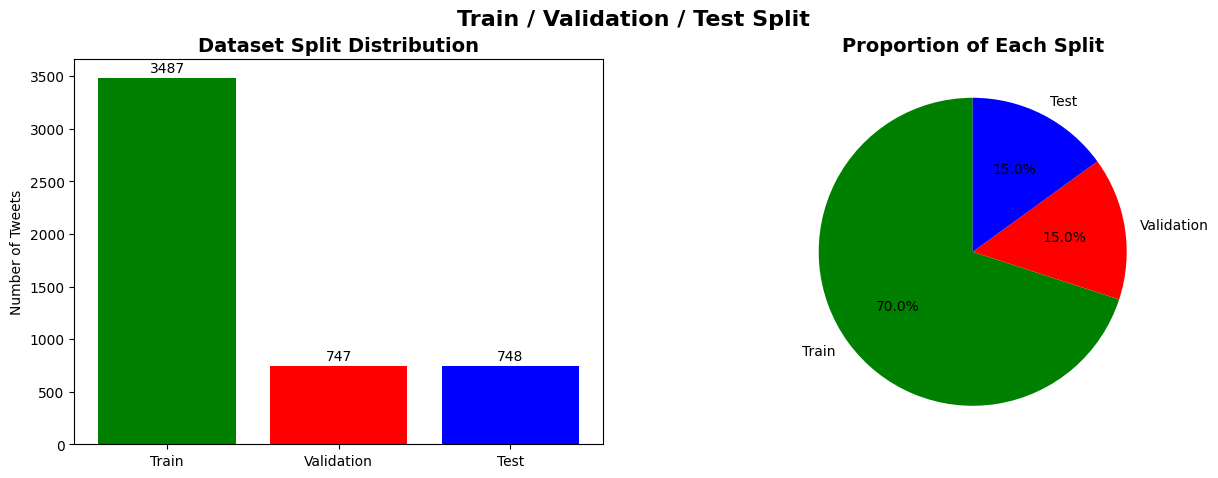

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 2.1 Taille des sets
sizes = [len(train_set), len(val_set), len(test_set)]
colors_bar = ['green', 'red', 'blue']
labels = ['Train','Validation','Test']

bars = axes[0].bar(labels, sizes, color=colors_bar)
axes[0].set_title('Dataset Split Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Tweets')

# Ajouter les valeurs sur les barres
for bar, size in zip(bars, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{size}', ha='center')


# 2.2 Pie chart des tailles
axes[1].pie(sizes, labels=labels, colors=colors_bar, autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Proportion of Each Split', fontsize=14, fontweight='bold')
plt.suptitle('Train / Validation / Test Split ',
             fontsize=16, fontweight='bold')
plt.show()


In [ ]:
#ETAPE 3 — Modèle Baseline

In [ ]:
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

train_set["label"] = train_set["Polarity Class"].str.lower().map(label_map)
val_set["label"] = val_set["Polarity Class"].str.lower().map(label_map)
test_set["label"] = test_set["Polarity Class"].str.lower().map(label_map)


In [ ]:
#trasform to HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_set[["clean_text", "label"]])
val_dataset = Dataset.from_pandas(val_set[["clean_text", "label"]])
test_dataset = Dataset.from_pandas(test_set[["clean_text", "label"]])


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "alger-ia/dziribert"

tokenizer = AutoTokenizer.from_pretrained(model_name)

id2label = {idx: label for label, idx in label_map.items()}
label2id = label_map

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print(f" Modèle chargé: {model_name}")
print(f"Classes: {label2id}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

 Modèle chargé: alger-ia/dziribert
Classes: {'negative': 0, 'neutral': 1, 'positive': 2}


In [ ]:
#tokenization
def tokenize_function(example):
    return tokenizer(
        example["clean_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)


Map:   0%|          | 0/3487 [00:00<?, ? examples/s]

Map:   0%|          | 0/747 [00:00<?, ? examples/s]

Map:   0%|          | 0/748 [00:00<?, ? examples/s]

In [ ]:
# Définir le format pour PyTorch
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print(f" Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

 Train: 3487 | Val: 747 | Test: 748


In [ ]:
# ============================================================
# 5. MÉTRIQUES
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    f1_macro = f1_score(labels, predictions, average='macro')
    f1_per_class = f1_score(labels, predictions, average=None)
    precision, recall, _, _ = precision_recall_fscore_support(labels, predictions, average=None)
    accuracy = accuracy_score(labels, predictions)
    g_mean = np.sqrt(np.prod(recall))

    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_negative': f1_per_class[0],
        'f1_neutral': f1_per_class[1],
        'f1_positive': f1_per_class[2],
        'precision_negative': precision[0],
        'precision_neutral': precision[1],
        'precision_positive': precision[2],
        'recall_negative': recall[0],
        'recall_neutral': recall[1],
        'recall_positive': recall[2],
        'g_mean': g_mean
    }


In [ ]:
from transformers import TrainingArguments

# ============================================================
# 6. CONFIGURATION
# ============================================================

training_args = TrainingArguments(
    output_dir="./baseline_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    seed=42,
    report_to="none"
)

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, precision_recall_fscore_support, accuracy_score
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Negative,F1 Neutral,F1 Positive,Precision Negative,Precision Neutral,Precision Positive,Recall Negative,Recall Neutral,Recall Positive,G Mean
1,No log,0.680624,0.704150,0.633633,0.698582,0.447552,0.754765,0.648026,0.711111,0.746231,0.757692,0.326531,0.763496,0.434622
2,No log,0.716623,0.713521,0.656532,0.694444,0.509091,0.766061,0.717213,0.626866,0.724771,0.673077,0.428571,0.812339,0.484075
3,0.578011,0.946703,0.709505,0.648669,0.696498,0.482759,0.766749,0.704724,0.552632,0.741007,0.688462,0.428571,0.794344,0.484123
4,0.578011,1.046771,0.720214,0.670981,0.702595,0.538462,0.771887,0.730290,0.583333,0.741706,0.676923,0.500000,0.804627,0.521858
5,0.197261,1.162134,0.713521,0.660217,0.690763,0.519337,0.770552,0.722689,0.566265,0.737089,0.661538,0.479592,0.807198,0.506062


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1090, training_loss=0.3649001401498777, metrics={'train_runtime': 642.1801, 'train_samples_per_second': 27.15, 'train_steps_per_second': 1.697, 'total_flos': 1146845609521920.0, 'train_loss': 0.3649001401498777, 'epoch': 5.0})

In [ ]:
results = trainer.evaluate(test_dataset)

print(" RÉSULTATS BASELINE:")
print(f"Accuracy: {results['eval_accuracy']:.4f}")
print(f"F1-macro: {results['eval_f1_macro']:.4f}")
print(f"G-mean: {results['eval_g_mean']:.4f}")
print("\nF1 par classe:")
print(f"  Negative: {results['eval_f1_negative']:.4f}")
print(f"  Neutral: {results['eval_f1_neutral']:.4f}")
print(f"  Positive: {results['eval_f1_positive']:.4f}")
print("\nRecall par classe:")
print(f"  Negative: {results['eval_recall_negative']:.4f}")
print(f"  Neutral: {results['eval_recall_neutral']:.4f}")
print(f"  Positive: {results['eval_recall_positive']:.4f}")

 RÉSULTATS BASELINE:
Accuracy: 0.7099
F1-macro: 0.6671
G-mean: 0.5293

F1 par classe:
  Negative: 0.6947
  Neutral: 0.5484
  Positive: 0.7583

Recall par classe:
  Negative: 0.6973
  Neutral: 0.5258
  Positive: 0.7641


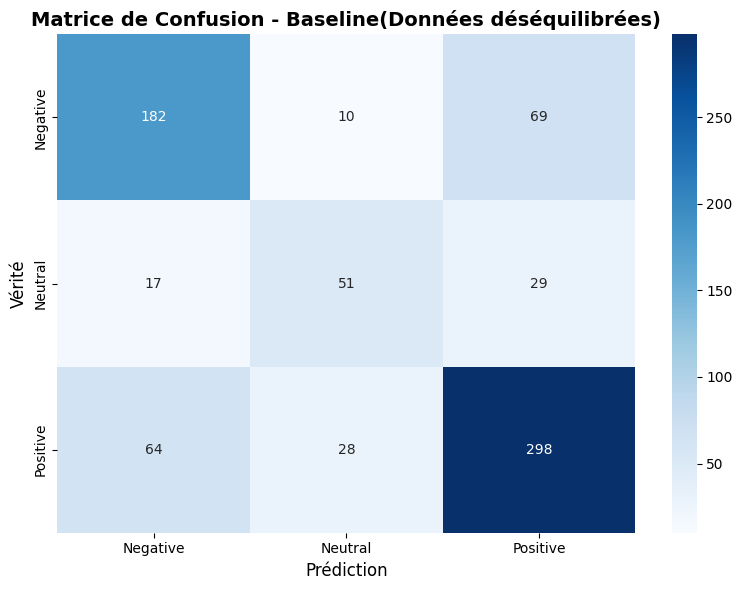

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prédictions sur le test set
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Matrice de Confusion - Baseline(Données déséquilibrées)',
          fontsize=14, fontweight='bold')
plt.xlabel('Prédiction', fontsize=12)
plt.ylabel('Vérité', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import json

# Sauvegarder les résultats de la baseline
baseline_results = {
    'model': 'DziriBERT',
    'configuration': 'Baseline (données brutes déséquilibrées)',
    'f1_macro': results['eval_f1_macro'],
    'f1_positive': results['eval_f1_positive'],
    'f1_negative': results['eval_f1_negative'],
    'f1_neutral': results['eval_f1_neutral'],
    'accuracy': results['eval_accuracy'],
    'g_mean': results['eval_g_mean'],
    'precision_positive': results['eval_precision_positive'],
    'precision_negative': results['eval_precision_negative'],
    'precision_neutral': results['eval_precision_neutral'],
    'recall_positive': results['eval_recall_positive'],
    'recall_negative': results['eval_recall_negative'],
    'recall_neutral': results['eval_recall_neutral']
}

# Sauvegarder en JSON
with open('baseline_results.json', 'w', encoding='utf-8') as f:
    json.dump(baseline_results, f, indent=4, ensure_ascii=False)

print(" Résultats baseline sauvegardés dans 'baseline_results.json'")

 Résultats baseline sauvegardés dans 'baseline_results.json'


In [ ]:
# ============================================================
# VARIANTE A: CLASS WEIGHTING
# ============================================================

import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
import json

# 1. TRAINER PERSONNALISÉ AVEC GESTION DES DEVICES

class WeightedLossTrainer(Trainer):

    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights
        self.loss_fn = None

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Créer la loss sur le même device que les logits
        if self.class_weights is not None:
            # Déplacer les poids sur le device des logits
            device = logits.device
            weights = self.class_weights.to(device)
            loss_fn = nn.CrossEntropyLoss(weight=weights)
        else:
            loss_fn = nn.CrossEntropyLoss()

        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# 2. CALCUL DES POIDS

# Compter les classes dans le train set
class_counts = train_set["Polarity Class"].value_counts()
total_examples = len(train_set)
num_classes = 3

print(f"\nDistribution dans train set:")
for classe, count in class_counts.items():
    print(f"  {classe}: {count} ({count/total_examples*100:.1f}%)")

# Calculer les poids
class_weights_dict = {}
for classe, count in class_counts.items():
    weight = total_examples / (num_classes * count)
    class_weights_dict[classe] = weight

print(f"\nPoids calculés:")
for classe, weight in class_weights_dict.items():
    print(f"  {classe}: {weight:.4f}")

weights_tensor = torch.tensor([
    class_weights_dict["Negative"],
    class_weights_dict["Neutral"],
    class_weights_dict["Positive"]
])

print(f"\nTensor de poids: {weights_tensor.numpy()}")

# 3. CHARGEMENT DU MODÈLE

model_name = "alger-ia/dziribert"

label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {0: "negative", 1: "neutral", 2: "positive"}

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# Vérifier le device du modèle
print(f"\nModèle sur device: {next(model.parameters()).device}")

# 4. PRÉPARATION DES DATASETS


# Ajouter les labels numériques
train_set["label"] = train_set["Polarity Class"].str.lower().map(label2id)
val_set["label"] = val_set["Polarity Class"].str.lower().map(label2id)
test_set["label"] = test_set["Polarity Class"].str.lower().map(label2id)

# Créer les datasets
train_dataset = Dataset.from_pandas(train_set[["clean_text", "label"]])
val_dataset = Dataset.from_pandas(val_set[["clean_text", "label"]])
test_dataset = Dataset.from_pandas(test_set[["clean_text", "label"]])

# Tokenisation
def tokenize_function(example):
    return tokenizer(
        example["clean_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format pour PyTorch
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print(f"\n Datasets préparés:")
print(f"  Train: {len(train_dataset)}")
print(f"  Val: {len(val_dataset)}")
print(f"  Test: {len(test_dataset)}")

# 5. MÉTRIQUES

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    f1_macro = f1_score(labels, predictions, average='macro')
    f1_per_class = f1_score(labels, predictions, average=None)
    precision, recall, _, _ = precision_recall_fscore_support(labels, predictions, average=None)
    accuracy = accuracy_score(labels, predictions)
    g_mean = np.sqrt(np.prod(recall))

    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_negative': f1_per_class[0],
        'f1_neutral': f1_per_class[1],
        'f1_positive': f1_per_class[2],
        'precision_negative': precision[0],
        'precision_neutral': precision[1],
        'precision_positive': precision[2],
        'recall_negative': recall[0],
        'recall_neutral': recall[1],
        'recall_positive': recall[2],
        'g_mean': g_mean
    }

# 6. CONFIGURATION

training_args = TrainingArguments(
    output_dir="./class_weighting_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    seed=42,
    report_to="none"
)

# 7. ENTRAÎNEMENT

print("\n" + "="*60)
print("ENTRAÎNEMENT AVEC CLASS WEIGHTING")
print("="*60)

# Créer le trainer avec les poids
trainer = WeightedLossTrainer(
    class_weights=weights_tensor,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# Lancer l'entraînement
trainer.train()

# 8. ÉVALUATION

print("\n" + "="*60)
print("ÉVALUATION SUR LE TEST SET")
print("="*60)

test_results = trainer.evaluate(test_dataset)

print("\n RÉSULTATS CLASS WEIGHTING:")
print("-"*50)
print(f"Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"F1-macro: {test_results['eval_f1_macro']:.4f}")
print(f"G-mean: {test_results['eval_g_mean']:.4f}")
print("\nF1 par classe:")
print(f"  Negative: {test_results['eval_f1_negative']:.4f}")
print(f"  Neutral: {test_results['eval_f1_neutral']:.4f} ← Classe minoritaire")
print(f"  Positive: {test_results['eval_f1_positive']:.4f}")

# 9. COMPARAISON AVEC BASELINE

try:
    with open('baseline_results.json', 'r') as f:
        baseline = json.load(f)

    print("\n" + "="*60)
    print("COMPARAISON BASELINE VS CLASS WEIGHTING")
    print("="*60)

    print(f"\n{'Métrique':<20} {'Baseline':>12} {'Class Weight':>12} {'Δ':>10}")
    print("-"*55)

    neutral_improvement = test_results['eval_f1_neutral'] - baseline.get('f1_neutral', 0)

    print(f"{'F1-macro':<20} {baseline.get('f1_macro', 0):>12.4f} {test_results['eval_f1_macro']:>12.4f} {test_results['eval_f1_macro'] - baseline.get('f1_macro', 0):>+10.4f}")
    print(f"{'F1-Neutral':<20} {baseline.get('f1_neutral', 0):>12.4f} {test_results['eval_f1_neutral']:>12.4f} {neutral_improvement:>+10.4f}")
    print(f"{'G-mean':<20} {baseline.get('g_mean', 0):>12.4f} {test_results['eval_g_mean']:>12.4f} {test_results['eval_g_mean'] - baseline.get('g_mean', 0):>+10.4f}")

    print(f"\n Amélioration sur classe Neutral: {neutral_improvement:+.4f} ({neutral_improvement*100:+.1f}%)")

except FileNotFoundError:
    print("\n Baseline non trouvée")

# ============================================================
# 10. SAUVEGARDE
# ============================================================

class_weighting_results = {
    'strategy': 'Class Weighting',
    'class_weights': {
        'negative': float(weights_tensor[0]),
        'neutral': float(weights_tensor[1]),
        'positive': float(weights_tensor[2])
    },
    'metrics': {
        'accuracy': test_results['eval_accuracy'],
        'f1_macro': test_results['eval_f1_macro'],
        'f1_negative': test_results['eval_f1_negative'],
        'f1_neutral': test_results['eval_f1_neutral'],
        'f1_positive': test_results['eval_f1_positive'],
        'g_mean': test_results['eval_g_mean']
    }
}

with open('class_weighting_results.json', 'w') as f:
    json.dump(class_weighting_results, f, indent=4)

print("\n Résultats sauvegardés dans 'class_weighting_results.json'")



In [ ]:
#FOCAL LOSS
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import Trainer
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

print("="*70)
print("STRATÉGIE 1 - VARIANTE B & C: FOCAL LOSS")
print("="*70)

# ============================================================
# 1. DÉFINITION DE FOCAL LOSS
# ============================================================

class FocalLoss(nn.Module):

    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):

        ce_loss = F.cross_entropy(inputs, targets, reduction='none')

        # Probabilité de la classe correcte
        pt = torch.exp(-ce_loss)

        # Focal Loss: (1 - pt)^γ * CE
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        # Application des poids alpha (si fournis)
        if self.alpha is not None:
            # Déplacer alpha sur le même device que targets
            alpha_t = self.alpha.to(targets.device)[targets]
            focal_loss = alpha_t * focal_loss

        return focal_loss.mean()


class FocalLossTrainer(Trainer):
    """
    Trainer personnalisé utilisant Focal Loss
    """
    def __init__(self, gamma=2.0, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.focal_loss = FocalLoss(gamma=gamma, alpha=class_weights)

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = self.focal_loss(logits, labels)
        return (loss, outputs) if return_outputs else loss


# ============================================================
# 2. PRÉPARATION DES MODÈLES ET DONNÉES
# ============================================================

# Réinitialiser le modèle pour chaque expérience
def get_fresh_model():
    """Créer un nouveau modèle DziriBERT non entraîné"""
    from transformers import AutoModelForSequenceClassification, AutoConfig

    config = AutoConfig.from_pretrained(
        "alger-ia/dziribert",
        num_labels=3,
        id2label={0: "negative", 1: "neutral", 2: "positive"},
        label2id={"negative": 0, "neutral": 1, "positive": 2}
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        "alger-ia/dziribert",
        config=config
    )
    return model

# ============================================================
# 3. VARIANTE B: FOCAL LOSS (γ=1)
# ============================================================

print("\n" + "="*60)
print("VARIANTE B - FOCAL LOSS γ=1")
print("="*60)

model_g1 = get_fresh_model()

trainer_g1 = FocalLossTrainer(
    gamma=1.0,
    class_weights=None,  # Pas de poids, uniquement Focal Loss
    model=model_g1,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("\nEntraînement avec Focal Loss γ=1...")
trainer_g1.train()
test_results_g1 = trainer_g1.evaluate(test_dataset)

print("\n RÉSULTATS FOCAL LOSS γ=1:")
print(f"  F1-macro: {test_results_g1['eval_f1_macro']:.4f}")
print(f"  F1-Neutral: {test_results_g1['eval_f1_neutral']:.4f}")

# ============================================================
# 4. VARIANTE B: FOCAL LOSS (γ=2)
# ============================================================

print("\n" + "="*60)
print("VARIANTE B - FOCAL LOSS γ=2")
print("="*60)

model_g2 = get_fresh_model()

trainer_g2 = FocalLossTrainer(
    gamma=2.0,
    class_weights=None,
    model=model_g2,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("\nEntraînement avec Focal Loss γ=2...")
trainer_g2.train()
test_results_g2 = trainer_g2.evaluate(test_dataset)

print("\n RÉSULTATS FOCAL LOSS γ=2:")
print(f"  F1-macro: {test_results_g2['eval_f1_macro']:.4f}")
print(f"  F1-Neutral: {test_results_g2['eval_f1_neutral']:.4f}")


# ============================================================
# TEST FOCAL LOSS AVEC γ=3
# ============================================================

print("="*60)
print("TEST FOCAL LOSS γ=3")
print("="*60)

# Créer un nouveau modèle
model_g3 = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# Trainer avec γ=3
trainer_g3 = FocalLossTrainer(
    gamma=3.0,
    class_weights=None,
    model=model_g3,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# Entraînement
trainer_g3.train()
test_results_g3 = trainer_g3.evaluate(test_dataset)

print(f"\n RÉSULTATS FOCAL LOSS γ=3:")
print(f"  F1-macro: {test_results_g3['eval_f1_macro']:.4f}")
print(f"  F1-Neutral: {test_results_g3['eval_f1_neutral']:.4f}")
print(f"  G-mean: {test_results_g3['eval_g_mean']:.4f}")


In [ ]:
# ============================================================
# 5. VARIANTE C: COMBINAISON (FOCAL LOSS γ=2 + CLASS WEIGHTS)
# ============================================================

print("\n" + "="*60)
print("VARIANTE C - FOCAL LOSS γ=2 + CLASS WEIGHTS")
print("="*60)

model_combined = get_fresh_model()

trainer_combined = FocalLossTrainer(
    gamma=2.0,
    class_weights=weights_tensor,  # Combiner avec les poids
    model=model_combined,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("\nEntraînement avec Focal Loss γ=2 + Class Weights...")
trainer_combined.train()
test_results_combined = trainer_combined.evaluate(test_dataset)

print("\n RÉSULTATS FOCAL LOSS γ=2 + CLASS WEIGHTS:")
print(f"  F1-macro: {test_results_combined['eval_f1_macro']:.4f}")
print(f"  F1-Neutral: {test_results_combined['eval_f1_neutral']:.4f}")

# ============================================================
# 6. TABLEAU COMPARATIF COMPLET
# ============================================================

print("\n" + "="*60)
print("TABLEAU COMPARATIF - BASELINE VS FOCAL LOSS")
print("="*60)

# Charger baseline
with open('baseline_results.json', 'r') as f:
    baseline = json.load(f)

# Créer le DataFrame de comparaison
comparison = pd.DataFrame({
    'Configuration': [
        'Baseline',
        'Focal Loss (γ=1)',
        'Focal Loss (γ=2)',
        'Focal Loss + Weights (γ=2)'
    ],
    'F1-macro': [
        baseline['f1_macro'],
        test_results_g1['eval_f1_macro'],
        test_results_g2['eval_f1_macro'],
        test_results_combined['eval_f1_macro']
    ],
    'F1-Positive': [
        baseline['f1_positive'],
        test_results_g1['eval_f1_positive'],
        test_results_g2['eval_f1_positive'],
        test_results_combined['eval_f1_positive']
    ],
    'F1-Negative': [
        baseline['f1_negative'],
        test_results_g1['eval_f1_negative'],
        test_results_g2['eval_f1_negative'],
        test_results_combined['eval_f1_negative']
    ],
    'F1-Neutral': [
        baseline['f1_neutral'],
        test_results_g1['eval_f1_neutral'],
        test_results_g2['eval_f1_neutral'],
        test_results_combined['eval_f1_neutral']
    ],
    'G-mean': [
        baseline['g_mean'],
        test_results_g1['eval_g_mean'],
        test_results_g2['eval_g_mean'],
        test_results_combined['eval_g_mean']
    ]
})

print("\n" + comparison.to_string(index=False))

# ============================================================
# 7. VISUALISATION COMPARATIVE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1: Comparaison F1-macro
configs = comparison['Configuration'].tolist()
f1_macro = comparison['F1-macro'].tolist()
f1_neutral = comparison['F1-Neutral'].tolist()

x = np.arange(len(configs))
width = 0.35

axes[0].bar(x - width/2, f1_macro, width, label='F1-macro', color='steelblue', edgecolor='black')
axes[0].bar(x + width/2, f1_neutral, width, label='F1-Neutral', color='coral', edgecolor='black')
axes[0].set_xlabel('Configuration', fontsize=12)
axes[0].set_ylabel('Score F1', fontsize=12)
axes[0].set_title('Comparaison: F1-macro vs F1-Neutral', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(configs, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Graphique 2: Amélioration par rapport à baseline
improvement = []
for i in range(1, len(configs)):
    imp = (comparison['F1-Neutral'].iloc[i] - comparison['F1-Neutral'].iloc[0]) * 100
    improvement.append(imp)

# Plotting the improvement with corrected label positioning
bars = axes[1].bar(configs[1:], improvement, color=['green' if val > 0 else 'red' for val in improvement], edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Configuration', fontsize=12)
axes[1].set_ylabel('Amélioration F1-Neutral (%)', fontsize=12)
axes[1].set_title('Amélioration sur la classe Neutral\n(par rapport à Baseline)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add labels to the bars
for i, bar_rect in enumerate(bars):
    val = improvement[i]
    y_pos = bar_rect.get_height() + (1 if val > 0 else -3)
    axes[1].text(bar_rect.get_x() + bar_rect.get_width()/2, y_pos,
                f'{val:+.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# 8. MATRICES DE CONFUSION COMPARATIVES
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

trainers_and_names = [
    (trainer_g1, 'Focal Loss γ=1', axes[0, 0]),
    (trainer_g2, 'Focal Loss γ=2', axes[0, 1]),
    (trainer_combined, 'Focal + Weights γ=2', axes[1, 0])
]

# Baseline matrix
predictions_baseline = trainer.predict(test_dataset) if 'trainer' in dir() else None

for trainer, name, ax in trainers_and_names:
    predictions = trainer.predict(test_dataset)
    y_pred = np.argmax(predictions.predictions, axis=-1)
    y_true = predictions.label_ids
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Prédiction', fontsize=10)
    ax.set_ylabel('Vérité', fontsize=10)

axes[1, 1].axis('off')
plt.suptitle('Matrices de Confusion - Focal Loss', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 9. SAUVEGARDE DES RÉSULTATS
# ============================================================

# Sauvegarder tous les résultats
all_focal_results = {
    'gamma1': test_results_g1,
    'gamma2': test_results_g2,
    'gamma_3': test_results_g3,
    'combined': test_results_combined
}

with open('focal_loss_results.json', 'w') as f:
    json.dump(all_focal_results, f, indent=4)

# Sauvegarder le tableau comparatif
comparison.to_csv('comparison_focal_loss.csv', index=False)

print("\n✓ Résultats sauvegardés:")
print("  - focal_loss_results.json")
print("  - comparison_focal_loss.csv")

# ============================================================
# 10. ANALYSE POUR LE RAPPORT
# ============================================================

print("\n" + "="*60)
print("ANALYSE POUR LE RAPPORT")
print("="*60)

best_gamma = "γ=2" if test_results_g2['eval_f1_neutral'] > test_results_g1['eval_f1_neutral'] else "γ=1"
best_f1 = max(test_results_g1['eval_f1_neutral'], test_results_g2['eval_f1_neutral'], test_results_combined['eval_f1_neutral'])

print("="*60)
print("✓ STRATÉGIE 1 - FOCAL LOSS TERMINÉE")
print("="*60)


In [ ]:
# ============================================================
# SAUVEGARDE UNIQUE (DÉBUT)
# ============================================================

from google.colab import drive
import pickle
import pandas as pd
import json

drive.mount('/content/drive')

# 1. Sauvegarder les splits
train_set.to_csv('/content/drive/MyDrive/train_set.csv', index=False)
val_set.to_csv('/content/drive/MyDrive/val_set.csv', index=False)
test_set.to_csv('/content/drive/MyDrive/test_set.csv', index=False)

# 2. Sauvegarder les textes clean
with open('/content/drive/MyDrive/texts_labels.pkl', 'wb') as f:
    pickle.dump({
        'train_texts': train_set['clean_text'].tolist(),
        'train_labels': train_set['Polarity Class'].tolist(),
        'val_texts': val_set['clean_text'].tolist(),
        'val_labels': val_set['Polarity Class'].tolist(),
        'test_texts': test_set['clean_text'].tolist(),
        'test_labels': test_set['Polarity Class'].tolist()
    }, f)

# 3. Sauvegarder les résultats de la Stratégie 1 (déjà faits)
with open('/content/drive/MyDrive/strategy1_results.json', 'w') as f:
    json.dump({
        'baseline': baseline_results,
        'class_weighting': class_weighting_results if 'class_weighting_results' in dir() else None,
        'focal_loss_gamma1': float(test_results_g1['eval_f1_neutral']) if 'test_results_g1' in dir() else None,
        'focal_loss_gamma2': float(test_results_g2['eval_f1_neutral']) if 'test_results_g2' in dir() else None,
    }, f)

print("✓ Sauvegarde initiale terminée!")



In [ ]:
# ============================================================
# STRATÉGIE 2 - BLOC 1: EXTRACTION DES EMBEDDINGS [CLS]
# ============================================================
# Objectif: Convertir chaque tweet en vecteur numérique de 768 dimensions
# Le vecteur [CLS] capture le sens global du tweet
# ============================================================

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import pickle
from google.colab import drive

print("="*70)
print("STRATÉGIE 2: RÉÉQUILIBRAGE DANS L'ESPACE DES EMBEDDINGS")
print("="*70)

# Monter Google Drive pour sauvegarde
drive.mount('/content/drive')

# ============================================================
# 1. CHARGEMENT DU MODÈLE DZIRIBERT (sans tête de classification)
# ============================================================

print("\n1. Chargement de DziriBERT en mode extraction...")

model_name = "alger-ia/dziribert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Mettre le modèle en mode évaluation (pas d'entraînement)
model.eval()

# Déplacer sur GPU si disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"   Modèle sur: {device}")

# ============================================================
# 2. FONCTION D'EXTRACTION DU VECTEUR [CLS]
# ============================================================

def extract_cls_embedding(text, tokenizer, model, device):
    """
    Extrait le vecteur [CLS] pour un texte donné
    Le vecteur [CLS] est une représentation globale du tweet (768 dimensions)
    """
    # Tokenisation
    inputs = tokenizer(
        text,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    # Déplacer sur GPU
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Extraction sans calcul de gradient (plus rapide)
    with torch.no_grad():
        outputs = model(**inputs)

    # Le vecteur [CLS] est le premier token de la séquence
    cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()

    return cls_embedding[0]

# ============================================================
# 3. EXTRACTION POUR TOUT LE TRAIN SET
# ============================================================

print("\n2. Extraction des embeddings [CLS] pour le train set...")
print(f"   Nombre de tweets à traiter: {len(train_set)}")

# Récupérer les textes et labels du train set
train_texts = train_set['clean_text'].tolist()
train_labels = train_set['Polarity Class'].tolist()

# Extraire les embeddings un par un
train_embeddings = []
valid_indices = []

for idx, text in enumerate(tqdm(train_texts, desc="Extraction embeddings")):
    try:
        embedding = extract_cls_embedding(text, tokenizer, model, device)
        train_embeddings.append(embedding)
        valid_indices.append(idx)
    except Exception as e:
        print(f"   Erreur sur tweet {idx}: {e}")
        continue

# Convertir en numpy array
X_train_emb = np.array(train_embeddings)
y_train_emb = np.array([train_labels[i] for i in valid_indices])

print(f"\n   ✓ Embeddings extraits: {X_train_emb.shape}")
print(f"     - {X_train_emb.shape[0]} tweets")
print(f"     - {X_train_emb.shape[1]} dimensions par tweet")

# ============================================================
# 4. VÉRIFICATION DE LA DISTRIBUTION
# ============================================================

print("\n3. Distribution des classes dans les embeddings:")
unique, counts = np.unique(y_train_emb, return_counts=True)
for label, count in zip(unique, counts):
    print(f"   {label}: {count} tweets ({count/len(y_train_emb)*100:.1f}%)")

# ============================================================
# 5. SAUVEGARDE DES EMBEDDINGS (pour éviter de refaire)
# ============================================================

print("\n4. Sauvegarde des embeddings...")

with open('/content/drive/MyDrive/train_embeddings.pkl', 'wb') as f:
    pickle.dump({
        'embeddings': X_train_emb,
        'labels': y_train_emb,
        'texts': [train_texts[i] for i in valid_indices]
    }, f)

print("   ✓ Embeddings sauvegardés dans Google Drive")

print("\n" + "="*70)
print("BLOC 1 TERMINÉ - Embeddings prêts pour SMOTE/ADASYN")
print("="*70)

In [ ]:
# ============================================================
# SMOTE
# ============================================================

from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report
import pandas as pd
import numpy as np
import pickle
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm


print("="*70)
print("SMOTE - TESTS COMPLETS (Équilibre total vs partiel)")
print("="*70)

# Re-load or re-define necessary components from previous cells
# Assuming `train_set`, `val_set`, `test_set` DataFrames are available from previous cells.
# And `extract_cls_embedding` function, `tokenizer`, `model`, `device` are defined in the preceding cell (`qKK5Nn8ZS_Cc`).

# Load the saved train embeddings
with open('/content/drive/MyDrive/train_embeddings.pkl', 'rb') as f:
    train_data = pickle.load(f)
X_train_emb = train_data['embeddings']
y_train_emb = train_data['labels']

# Ensure tokenizer, model, device are ready for new extractions if needed
# This part assumes `qKK5Nn8ZS_Cc` was executed and these are in scope.
# If not, they would need to be re-initialized here.
model_name = "alger-ia/dziribert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def extract_cls_embedding(text, tokenizer, model, device):
    inputs = tokenizer(text, padding=True, truncation=True, max_length=128, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :].cpu().numpy()[0]

# Extract embeddings for validation and test sets
print("\nExtracting embeddings for validation set...")
val_embeddings = []
for text in tqdm(val_set['clean_text'].tolist(), desc="Val Embeddings"):
    val_embeddings.append(extract_cls_embedding(text, tokenizer, model, device))
X_val_emb = np.array(val_embeddings)
y_val_emb = val_set['Polarity Class'].tolist()

print("\nExtracting embeddings for test set...")
test_embeddings = []
for text in tqdm(test_set['clean_text'].tolist(), desc="Test Embeddings"):
    test_embeddings.append(extract_cls_embedding(text, tokenizer, model, device))
X_test_emb = np.array(test_embeddings)
y_test_emb = test_set['Polarity Class'].tolist()

# Encode labels
print("\nEncoding labels...")
le = LabelEncoder()
y_encoded = le.fit_transform(y_train_emb)
y_val_encoded = le.transform(y_val_emb)
y_test_encoded = le.transform(y_test_emb)

# 1. Normalisation des embeddings (obligatoire pour SMOTE)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_emb)
X_test_scaled = scaler.transform(X_test_emb)
X_val_scaled = scaler.transform(X_val_emb)

# ============================================================
# TEST 1: SMOTE avec équilibre TOTAL (33% par classe)
# ============================================================

print("\n" + "="*50)
print("TEST 1: SMOTE - ÉQUILIBRE TOTAL")
print("="*50)

smote_total = SMOTE(random_state=42, sampling_strategy='auto')
X_smote_total, y_smote_total = smote_total.fit_resample(X_train_scaled, y_encoded)

print(f"Distribution après SMOTE total:")
unique, counts = np.unique(y_smote_total, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {le.inverse_transform([label])[0]}: {count}")

# Entraînement SVM
svm_total = SVC(kernel='rbf', C=1.0, random_state=42)
svm_total.fit(X_smote_total, y_smote_total)

# Évaluation
y_pred_total = svm_total.predict(X_test_scaled)
f1_neutral_total = f1_score(y_test_encoded, y_pred_total, average=None)[1]
f1_macro_total = f1_score(y_test_encoded, y_pred_total, average='macro')

print(f"\nRésultats SMOTE équilibre total:")
print(f"  F1-macro: {f1_macro_total:.4f}")
print(f"  F1-Neutral: {f1_neutral_total:.4f}")

# ============================================================
# TEST 2: SMOTE avec équilibre PARTIEL (Neutral à 25%)
# ============================================================

print("\n" + "="*50)
print("TEST 2: SMOTE - ÉQUILIBRE PARTIEL (Neutral à 25%)")
print("="*50)

# Calculer combien de Neutral on veut (25% du total après augmentation)
current_counts = {i: np.sum(y_encoded == i) for i in range(3)}
current_total = sum(current_counts.values())
target_neutral = int(current_total * 0.25)  # 25% de Neutral
target_negative = current_counts[0]        # Garder Negative identique
target_positive = current_counts[2]        # Garder Positive identique

sampling_strategy_partial = {
    0: target_negative,
    1: target_neutral,
    2: target_positive
}

print(f"Stratégie d'échantillonnage:")
print(f"  Negative: {target_negative} (conservé)")
print(f"  Neutral: {target_neutral} (augmenté à 25% du total)")
print(f"  Positive: {target_positive} (conservé)")

smote_partial = SMOTE(random_state=42, sampling_strategy=sampling_strategy_partial)
X_smote_partial, y_smote_partial = smote_partial.fit_resample(X_train_scaled, y_encoded)

print(f"\nDistribution après SMOTE partiel:")
unique, counts = np.unique(y_smote_partial, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {le.inverse_transform([label])[0]}: {count}")

# Entraînement
svm_partial = SVC(kernel='rbf', C=1.0, random_state=42)
svm_partial.fit(X_smote_partial, y_smote_partial)

# Évaluation
y_pred_partial = svm_partial.predict(X_test_scaled)
f1_neutral_partial = f1_score(y_test_encoded, y_pred_partial, average=None)[1]
f1_macro_partial = f1_score(y_test_encoded, y_pred_partial, average='macro')

print(f"\nRésultats SMOTE équilibre partiel:")
print(f"  F1-macro: {f1_macro_partial:.4f}")
print(f"  F1-Neutral: {f1_neutral_partial:.4f}")

# ============================================================
# TEST 3: TEST AVEC DIFFÉRENTS k_neighbors
# ============================================================

print("\n" + "="*50)
print("TEST 3: SMOTE - k_neighbors variables")
print("="*50)

k_values = [3, 5, 7, 9]
k_results = []

for k in k_values:
    print(f"\n▶ Test avec k = {k}")

    smote_k = SMOTE(random_state=42, k_neighbors=k, sampling_strategy='auto')
    X_smote_k, y_smote_k = smote_k.fit_resample(X_train_scaled, y_encoded)

    svm_k = SVC(kernel='rbf', C=1.0, random_state=42)
    svm_k.fit(X_smote_k, y_smote_k)

    y_pred_k = svm_k.predict(X_test_scaled)
    f1_neutral_k = f1_score(y_test_encoded, y_pred_k, average=None)[1]
    f1_macro_k = f1_score(y_test_encoded, y_pred_k, average='macro')

    k_results.append({
        'k': k,
        'f1_macro': f1_macro_k,
        'f1_neutral': f1_neutral_k
    })

    print(f"    F1-macro: {f1_macro_k:.4f}")
    print(f"    F1-Neutral: {f1_neutral_k:.4f}")

# ============================================================
# TABLEAU COMPARATIF COMPLET SMOTE
# ============================================================

print("\n" + "="*70)
print("TABLEAU COMPARATIF - SMOTE")
print("="*70)

# Charger baseline
import json
with open('baseline_results.json', 'r') as f:
    baseline = json.load(f)

smote_comparison = pd.DataFrame({
    'Configuration': [
        'Baseline',
        'SMOTE (équilibre total)',
        'SMOTE (partiel 25%)',
        'SMOTE k=3',
        'SMOTE k=5',
        'SMOTE k=7',
        'SMOTE k=9'
    ],
    'F1-macro': [
        baseline['f1_macro'],
        f1_macro_total,
        f1_macro_partial,
        k_results[0]['f1_macro'],
        k_results[1]['f1_macro'],
        k_results[2]['f1_macro'],
        k_results[3]['f1_macro']
    ],
    'F1-Neutral': [
        baseline['f1_neutral'],
        f1_neutral_total,
        f1_neutral_partial,
        k_results[0]['f1_neutral'],
        k_results[1]['f1_neutral'],
        k_results[2]['f1_neutral'],
        k_results[3]['f1_neutral']
    ]
})

print(smote_comparison.to_string(index=False))

# ============================================================
# GRAPHIQUE COMPARATIF
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

configs = smote_comparison['Configuration'].tolist()
f1_macro_values = smote_comparison['F1-macro'].tolist()
f1_neutral_values = smote_comparison['F1-Neutral'].tolist()

x = np.arange(len(configs))
width = 0.35

bars1 = ax.bar(x - width/2, f1_macro_values, width, label='F1-macro', color='steelblue')
bars2 = ax.bar(x + width/2, f1_neutral_values, width, label='F1-Neutral', color='coral')

ax.set_xlabel('Configuration', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('SMOTE: Comparaison des différentes configurations', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0.45, 0.75)
ax.grid(axis='y', alpha=0.3)

# Ajouter les valeurs
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Sauvegarde des résultats SMOTE
smote_all_results = {
    'equilibre_total': {
        'f1_macro': f1_macro_total,
        'f1_neutral': f1_neutral_total
    },
    'equilibre_partiel_25': {
        'f1_macro': f1_macro_partial,
        'f1_neutral': f1_neutral_partial
    },
    'k_neighbors': {f"k={k['k']}": {'f1_macro': k['f1_macro'], 'f1_neutral': k['f1_neutral']} for k in k_results}
}

with open('/content/drive/MyDrive/smote_all_results.json', 'w') as f:
    json.dump(smote_all_results, f, indent=4)

print("\n✓ Résultats SMOTE sauvegardés")

In [ ]:
# ============================================================
# ADASYN
# ============================================================

from imblearn.over_sampling import ADASYN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import pickle
from google.colab import drive
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModel

drive.mount('/content/drive')

# ============================================================
# ÉTAPE 1: CHARGEMENT ET NETTOYAGE
# ============================================================

print("="*70)
print("ADASYN - AVEC CORRECTIONS NaN")
print("="*70)

# Charger les splits
train_set = pd.read_csv('/content/drive/MyDrive/train_set.csv')
val_set = pd.read_csv('/content/drive/MyDrive/val_set.csv')
test_set = pd.read_csv('/content/drive/MyDrive/test_set.csv')

# Nettoyer toutes les colonnes clean_text
for df in [train_set, val_set, test_set]:
    df['clean_text'] = df['clean_text'].fillna('').astype(str)
    df['clean_text'] = df['clean_text'].apply(lambda x: x if x.strip() != '' else None)

# Supprimer les lignes avec None
train_set = train_set[train_set['clean_text'].notna()]
val_set = val_set[val_set['clean_text'].notna()]
test_set = test_set[test_set['clean_text'].notna()]

print(f"\nTrain: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

# ============================================================
# ÉTAPE 2: CHARGEMENT DES EMBEDDINGS TRAIN
# ============================================================

with open('/content/drive/MyDrive/train_embeddings.pkl', 'rb') as f:
    train_data = pickle.load(f)
    X_train_emb = train_data['embeddings']
    y_train_emb = train_data['labels']

print(f"\nTrain embeddings: {X_train_emb.shape}")

# Encodage
le = LabelEncoder()
y_encoded = le.fit_transform(y_train_emb)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_emb)

# ============================================================
# ÉTAPE 3: CHARGEMENT MODÈLE POUR EXTRACTION TEST
# ============================================================

tokenizer = AutoTokenizer.from_pretrained("alger-ia/dziribert")
model = AutoModel.from_pretrained("alger-ia/dziribert")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

def extract_cls_safe(text):
    if text is None or not isinstance(text, str) or text.strip() == "":
        return None
    try:
        inputs = tokenizer(text, padding=True, truncation=True, max_length=128, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        return outputs.last_hidden_state[:, 0, :].cpu().numpy()[0]
    except:
        return None

# ============================================================
# ÉTAPE 4: EXTRACTION TEST SET
# ============================================================

print("\nExtraction test embeddings...")
test_texts = test_set['clean_text'].tolist()
X_test_list = []
y_test_list = []

for text in tqdm(test_texts):
    emb = extract_cls_safe(text)
    if emb is not None:
        X_test_list.append(emb)
        y_test_list.append(test_set.loc[test_set['clean_text'] == text, 'Polarity Class'].iloc[0])

X_test_emb = np.array(X_test_list)
y_test_emb = np.array(y_test_list)
y_test_encoded = le.transform(y_test_emb)
X_test_scaled = scaler.transform(X_test_emb)

print(f"Test embeddings: {X_test_emb.shape}")

# ============================================================
# ÉTAPE 5: ADASYN
# ============================================================

print("\n" + "="*50)
print("ADASYN PAR DÉFAUT")
print("="*50)

adasyn = ADASYN(random_state=42, n_neighbors=5)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_encoded)

svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_adasyn, y_adasyn)

y_pred = svm.predict(X_test_scaled)
f1_macro = f1_score(y_test_encoded, y_pred, average='macro')
f1_per_class = f1_score(y_test_encoded, y_pred, average=None)

print(f"\n📊 RÉSULTATS ADASYN:")
print(f"  F1-macro: {f1_macro:.4f}")
print(f"  F1-Negative: {f1_per_class[0]:.4f}")
print(f"  F1-Neutral: {f1_per_class[1]:.4f}")
print(f"  F1-Positive: {f1_per_class[2]:.4f}")

print("\n ADASYN terminé avec succès!")

In [ ]:
# ============================================================
# VISUALISATION AVEC LA MEILLEURE CONFIGURATION SMOTE
# ============================================================

# Trouver la meilleure configuration (celle avec le meilleur F1-Neutral)
best_k_index = max(range(len(k_results)), key=lambda i: k_results[i]['f1_neutral'])
best_k = k_results[best_k_index]['k']

# Recréer SMOTE avec le meilleur k
from imblearn.over_sampling import SMOTE

smote_best = SMOTE(random_state=42, k_neighbors=best_k, sampling_strategy='auto')
X_smote_best, y_smote_best = smote_best.fit_resample(X_train_scaled, y_encoded)

print(f"Utilisation de la meilleure configuration: k={best_k}")

# Puis visualisation avec X_smote_best et y_smote_best
X_smote = X_smote_best
y_smote = y_smote_best

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

print("="*70)
print("VISUALISATION DES EMBEDDINGS APRÈS SMOTE")
print("(Pour la section 5.2 du rapport)")
print("="*70)

# Réduction PCA
pca = PCA(n_components=2, random_state=42)
X_smote_pca = pca.fit_transform(X_smote)

# Distribution après SMOTE
print("\nDistribution après SMOTE:")
unique, counts = np.unique(y_smote, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {le.inverse_transform([label])[0]}: {count} ({count/len(y_smote)*100:.1f}%)")

# Graphique
plt.figure(figsize=(10, 8))

colors = {0: 'red', 1: 'blue', 2: 'green'}
labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

for label_id, color in colors.items():
    mask = y_smote == label_id
    plt.scatter(
        X_smote_pca[mask, 0],
        X_smote_pca[mask, 1],
        c=color,
        label=labels[label_id],
        alpha=0.5,
        s=15,
        edgecolors='black',
        linewidth=0.3
    )

plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title('Distribution des classes APRÈS SMOTE\n(Rééquilibrage dans l\'espace des embeddings)',
          fontsize=14, fontweight='bold')
plt.legend(title='Sentiment', loc='best')
plt.grid(True, alpha=0.3)

# Ajouter les proportions
plt.text(0.02, 0.98, f'Positive: {np.sum(y_smote == 2)}\nNegative: {np.sum(y_smote == 0)}\nNeutral: {np.sum(y_smote == 1)}',
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/embeddings_apres_smote.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Graphique sauvegardé: embeddings_apres_smote.png")

In [ ]:
# ============================================================
# ANALYSE VISUELLE: Pourquoi SMOTE n'a pas fonctionné
# ============================================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

print("="*70)
print("ANALYSE: Pourquoi SMOTE n'a pas amélioré les performances")
print("="*70)

# ============================================================
# 1. Préparer les données AVANT et APRÈS SMOTE
# ============================================================

# Données originales
pca = PCA(n_components=2, random_state=42)
X_original_pca = pca.fit_transform(X_train_scaled)
X_smote_pca = pca.transform(X_smote)  # Utiliser le même PCA

# ============================================================
# 2. Créer une figure avec 3 sous-graphiques
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors_map = {0: 'red', 1: 'blue', 2: 'green'}
labels_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

# ============================================================
# Graphique 1: Données originales (AVANT SMOTE)
# ============================================================

ax1 = axes[0]
for label_id, color in colors_map.items():
    mask = y_encoded == label_id
    ax1.scatter(
        X_original_pca[mask, 0],
        X_original_pca[mask, 1],
        c=color,
        label=labels_map[label_id],
        alpha=0.6,
        s=15,
        edgecolors='black',
        linewidth=0.3
    )

# Ajouter un cercle pour montrer la zone de chevauchement
circle = Circle((0, 0), 3, fill=False, edgecolor='black', linewidth=2.5, linestyle='--')
ax1.add_patch(circle)
ax1.annotate('Zone de chevauchement\n(Neutral mélangé)', xy=(0, 0), xytext=(-4, 3),
             fontsize=10, color='black', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='black'))

ax1.set_title('AVANT SMOTE\nDonnées originales déséquilibrées', fontsize=12, fontweight='bold')
ax1.set_xlabel('PCA Component 1', fontsize=10)
ax1.set_ylabel('PCA Component 2', fontsize=10)
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

# Annotations
neutral_count = np.sum(y_encoded == 1)
ax1.text(0.02, 0.98, f'Neutral: {neutral_count} points\n(13% du corpus)',
         transform=ax1.transAxes, fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ============================================================
# Graphique 2: Données APRÈS SMOTE
# ============================================================

ax2 = axes[1]

# Afficher d'abord les points originaux (en arrière-plan, plus clairs)
for label_id, color in colors_map.items():
    mask = y_encoded == label_id
    ax2.scatter(
        X_original_pca[mask, 0],
        X_original_pca[mask, 1],
        c=color,
        alpha=0.2,
        s=10,
    )

# Afficher les points SMOTE (en avant-plan)
for label_id, color in colors_map.items():
    mask = y_smote == label_id
    # Déterminer si ce sont des points originaux ou synthétiques
    alpha = 0.7 if label_id == 1 else 0.4
    size = 20 if label_id == 1 else 12
    marker = '^' if label_id == 1 else 'o'

    ax2.scatter(
        X_smote_pca[mask, 0],
        X_smote_pca[mask, 1],
        c=color,
        alpha=alpha,
        s=size,
        marker=marker,
        edgecolors='black' if label_id == 1 else 'none',
        linewidth=0.3
    )

# Ajouter une flèche pour montrer les nouveaux points
ax2.annotate('Nouveaux points\nsynthétiques Neutral', xy=(2, 2), xytext=(3, -2),
             fontsize=9, color='black', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='black'))

ax2.set_title('APRÈS SMOTE\nDonnées rééquilibrées artificiellement', fontsize=12, fontweight='bold')
ax2.set_xlabel('PCA Component 1', fontsize=10)
ax2.set_ylabel('PCA Component 2', fontsize=10)
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

neutral_count_smote = np.sum(y_smote == 1)
ax2.text(0.02, 0.98, f'Neutral: {neutral_count_smote} points\n(33% après SMOTE)',
         transform=ax2.transAxes, fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ============================================================
# Graphique 3: Illustration du problème (schéma explicatif)
# ============================================================

ax3 = axes[2]

# Schéma simplifié pour expliquer le problème
ax3.set_xlim(-4, 4)
ax3.set_ylim(-3, 3)
ax3.set_facecolor('#f0f0f0')

# Dessiner les zones
from matplotlib.patches import Polygon

# Zone Positive
pos_zone = Polygon([(1, -2), (4, 0), (3, 2), (0, 1)], alpha=0.3, color='green')
# Zone Negative
neg_zone = Polygon([(-4, -1), (-1, -2), (0, 0), (-3, 2)], alpha=0.3, color='red')
# Zone Neutral (petite zone entre les deux)
neu_zone = Polygon([(-1, -0.5), (1, -0.5), (1.5, 0.5), (-0.5, 1)], alpha=0.3, color='blue')

ax3.add_patch(pos_zone)
ax3.add_patch(neg_zone)
ax3.add_patch(neu_zone)

# Points originaux Neutral
np.random.seed(42)
orig_x = np.random.uniform(-0.5, 1.5, 20)
orig_y = np.random.uniform(-0.5, 1, 20)
ax3.scatter(orig_x, orig_y, c='blue', s=50, edgecolors='black', zorder=5, label='Neutral original')

# Points synthétiques (créés par interpolation)
synth_x = np.random.uniform(-1, 2, 40)
synth_y = np.random.uniform(-1, 1.5, 40)
ax3.scatter(synth_x, synth_y, c='darkorange', s=20, alpha=0.6, edgecolors='blue', zorder=4, label='Points synthétiques')

# Flèches d'interpolation
for i in range(5):
    ax3.annotate('', xy=(synth_x[i], synth_y[i]), xytext=(orig_x[i % 20], orig_y[i % 20]),
                 arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, lw=0.5))

# Légende personnalisée
ax3.set_title('Problème: Interpolation linéaire\ncrée des points dans des zones ambiguës',
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Espace des embeddings', fontsize=10)
ax3.set_ylabel('Espace des embeddings', fontsize=10)
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(True, alpha=0.2)

# Annotation
ax3.text(0.5, -2.5, 'Un point synthétique peut tomber\nentre Positive et Neutral → ambigu',
         fontsize=9, ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Pourquoi SMOTE n\'a pas amélioré les performances sur TWIFL',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/smote_analyse_pourquoi.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# STRATÉGIE 3 BACK TRANSACTION- BLOC 1: INSTALLATION ET CHARGEMENT
# ============================================================

print("="*70)
print("STRATÉGIE 3: BACK-TRANSLATION")
print("="*70)

# Installer les bibliothèques nécessaires
!pip install sentencepiece sacremoses -q

from transformers import MarianMTModel, MarianTokenizer
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import time

# ============================================================
# 1. CHARGEMENT DES MODÈLES DE TRADUCTION
# ============================================================

print("\n1. Chargement des modèles de traduction...")

# Modèle: Arabe → Français
model_name_ar_fr = "Helsinki-NLP/opus-mt-ar-fr"
tokenizer_ar_fr = MarianTokenizer.from_pretrained(model_name_ar_fr)
model_ar_fr = MarianMTModel.from_pretrained(model_name_ar_fr)

# Modèle: Français → Arabe
model_name_fr_ar = "Helsinki-NLP/opus-mt-fr-ar"
tokenizer_fr_ar = MarianTokenizer.from_pretrained(model_name_fr_ar)
model_fr_ar = MarianMTModel.from_pretrained(model_name_fr_ar)

print(f"   ✓ Modèle Arabe→Français chargé")
print(f"   ✓ Modèle Français→Arabe chargé")

# Déplacer sur GPU si disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ar_fr = model_ar_fr.to(device)
model_fr_ar = model_fr_ar.to(device)
print(f"   ✓ Modèles sur: {device}")

In [ ]:
# ============================================================
# STRATÉGIE 3 - BLOC 2: SÉLECTION ET TRADUCTION
# ============================================================

print("\n" + "="*70)
print("PHASE 1 & 2: Sélection et Traduction")
print("="*70)

# ============================================================
# 1. SÉLECTION DES TWEETS NEUTRAL
# ============================================================

# Identifier les tweets Neutral dans le train set
neutral_tweets = train_set[train_set["Polarity Class"] == "Neutral"]
neutral_texts = neutral_tweets["clean_text"].tolist()
neutral_original_labels = neutral_tweets["Polarity Class"].tolist()

print(f"\nTweets Neutral dans train set: {len(neutral_texts)}")
print(f"Pourcentage: {len(neutral_texts)/len(train_set)*100:.1f}%")

# Afficher quelques exemples
print("\nExemples de tweets Neutral:")
for i, text in enumerate(neutral_texts[:5]):
    print(f"  {i+1}. {text[:80]}...")

# ============================================================
# 2. FONCTION DE TRADUCTION
# ============================================================

def translate(text, model, tokenizer, device, max_length=128):
    """
    Traduire un texte d'une langue à une autre
    """
    if not text or text == "":
        return ""

    # Tokenisation
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Traduction
    with torch.no_grad():
        translated = model.generate(**inputs, max_length=max_length)

    # Décodage
    result = tokenizer.decode(translated[0], skip_special_tokens=True)

    return result

# Tester la fonction
print("\nTest de traduction:")
test_text = "شفت الفيلم وكان عادي"
print(f"Original: {test_text}")
print(f"Arabe→Français: {translate(test_text, model_ar_fr, tokenizer_ar_fr, device)}")

In [ ]:
# ============================================================
# STRATÉGIE 3 - BLOC 3: BACK-TRANSLATION COMPLÈTE
# ============================================================

print("\n" + "="*70)
print("PHASES 1-4: Back-Translation + Filtrage")
print("="*70)

# ============================================================
# 1. CHARGER DZIRIBERT POUR LES EMBEDDINGS
# ============================================================

print("\n1. Chargement de DziriBERT pour le filtrage...")

from transformers import AutoTokenizer, AutoModel

model_name = "alger-ia/dziribert"
tokenizer_dziri = AutoTokenizer.from_pretrained(model_name)
model_dziri = AutoModel.from_pretrained(model_name)
model_dziri = model_dziri.to(device)
model_dziri.eval()

def get_embedding(text):
    """Extraire l'embedding [CLS] d'un texte"""
    inputs = tokenizer_dziri(text, return_tensors="pt", truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model_dziri(**inputs)

    return outputs.last_hidden_state[:, 0, :].cpu().numpy()[0]

# ============================================================
# 2. BACK-TRANSLATION POUR CHAQUE TWEET NEUTRAL
# ============================================================

print("\n2. Application de la Back-Translation...")

back_translated_tweets = []
failed_tweets = []

for idx, original_text in enumerate(neutral_texts):
    if idx % 50 == 0:
        print(f"   Traitement: {idx}/{len(neutral_texts)}")

    try:
        # Phase 2: Arabe → Français
        french_text = translate(original_text, model_ar_fr, tokenizer_ar_fr, device)

        if not french_text or french_text == "":
            failed_tweets.append(original_text)
            continue

        # Phase 3: Français → Arabe
        back_translated = translate(french_text, model_fr_ar, tokenizer_fr_ar, device)

        if not back_translated or back_translated == "":
            failed_tweets.append(original_text)
            continue

        # Stocker
        back_translated_tweets.append({
            'original': original_text,
            'french': french_text,
            'back_translated': back_translated,
            'sentiment': 'Neutral'
        })

    except Exception as e:
        failed_tweets.append(original_text)
        continue

print(f"\n✓ Back-Translation terminée")
print(f"   Réussies: {len(back_translated_tweets)}/{len(neutral_texts)}")
print(f"   Échouées: {len(failed_tweets)}")

# ============================================================
# 3. PHASE 4: FILTRAGE PAR SIMILARITÉ COSINUS
# ============================================================

print("\n3. Filtrage par similarité cosinus (seuil 0.5 - 0.85)...")

filtered_tweets = []
similarity_stats = []

for item in back_translated_tweets:
    # Embeddings original et back-translated
    emb_original = get_embedding(item['original'])
    emb_back = get_embedding(item['back_translated'])

    # Similarité cosinus
    similarity = cosine_similarity([emb_original], [emb_back])[0][0]
    similarity_stats.append(similarity)

    # Filtrage
    if 0.5 <= similarity <= 0.85:
        filtered_tweets.append({
            'original': item['original'],
            'back_translated': item['back_translated'],
            'similarity': similarity,
            'sentiment': 'Neutral'
        })

print(f"\n✓ Filtrage terminé")
print(f"   Avant filtrage: {len(back_translated_tweets)}")
print(f"   Après filtrage: {len(filtered_tweets)}")
print(f"   Taux de conservation: {len(filtered_tweets)/len(back_translated_tweets)*100:.1f}%")

# Statistiques de similarité
stats = {
    'mean': np.mean(similarity_stats),
    'std': np.std(similarity_stats),
    'min': np.min(similarity_stats),
    'max': np.max(similarity_stats)
}

print(f"\nStatistiques de similarité:")
print(f"   Moyenne: {stats['mean']:.4f}")
print(f"   Écart-type: {stats['std']:.4f}")
print(f"   Min: {stats['min']:.4f}")
print(f"   Max: {stats['max']:.4f}")

In [ ]:
# ============================================================
# STRATÉGIE 3 - BLOC 4 TESTS AVEC TAUX ADAPTÉS
# ============================================================

print("\n" + "="*70)
print("TESTS BACK-TRANSLATION (Taux adaptés sans doublons)")
print("="*70)

# ============================================================
# 1. VÉRIFICATION DES DONNÉES DISPONIBLES
# ============================================================

original_neutral_count = len(neutral_texts)  # 455
available_paraphrases = len(filtered_tweets)  # 196

print(f"\nTweets Neutral originaux: {original_neutral_count}")
print(f"Paraphrases disponibles après filtrage: {available_paraphrases}")
print(f"Taux maximum réalisable: {available_paraphrases/original_neutral_count*100:.1f}%")

# ============================================================
# 2. DÉFINITION DES TAUX ADAPTÉS (SANS DOUBLONS)
# ============================================================

# Taux adaptés à la réalité des données
# 20% = recommandé par le sujet
# 43% = maximum réalisable (équivaut à la limite de 50/100%)
augmentation_tests = [
    {'name': '20% (recommandé)', 'rate': 0.20, 'paraphrases': int(original_neutral_count * 0.20)},
    {'name': '43% (max - équivaut 50/100%)', 'rate': available_paraphrases/original_neutral_count, 'paraphrases': available_paraphrases}
]

print("\nTaux à tester:")
for test in augmentation_tests:
    print(f"  • {test['name']}: {test['paraphrases']} paraphrases ({test['rate']*100:.0f}%)")

# ============================================================
# 3. CRÉATION DES TRAIN SETS AUGMENTÉS
# ============================================================

print("\n" + "="*50)
print("CRÉATION DES DATASETS AUGMENTÉS")
print("="*50)

augmented_datasets = []

for test in augmentation_tests:
    print(f"\n▶ {test['name']}")
    print(f"   Paraphrases à ajouter: {test['paraphrases']}")

    # Sélectionner les paraphrases (sans doublons)
    selected = filtered_tweets[:test['paraphrases']]

    # Créer nouveau train set
    train_augmented = train_set.copy()

    # Ajouter les paraphrases
    new_rows = []
    for p in selected:
        new_rows.append({
            'clean_text': p['back_translated'],
            'Polarity Class': 'Neutral'
        })

    df_new = pd.DataFrame(new_rows)
    train_augmented = pd.concat([train_augmented, df_new], ignore_index=True)

    augmented_datasets.append({
        'name': test['name'],
        'rate': test['rate'],
        'train_set': train_augmented,
        'neutral_original': original_neutral_count,
        'neutral_new': len(selected),
        'neutral_total': original_neutral_count + len(selected)
    })

    print(f"    Neutral: {original_neutral_count} → {original_neutral_count + len(selected)} (+{len(selected)})")
    print(f"    Taille totale train set: {len(train_augmented)}")

# ============================================================
# 4. ENTRAÎNEMENT ET ÉVALUATION
# ============================================================

print("\n" + "="*70)
print("ENTRAÎNEMENT ET ÉVALUATION")
print("="*70)

from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("alger-ia/dziribert")

# Mapping des labels
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {0: "negative", 1: "neutral", 2: "positive"}

final_results = []

for aug in augmented_datasets:
    print(f"\n{'='*50}")
    print(f"ENTRAÎNEMENT: {aug['name']}")
    print(f"{'='*50}")

    # Préparer les datasets
    train_aug = aug['train_set']
    train_aug["label"] = train_aug["Polarity Class"].str.lower().map(label2id)

    # Datasets HuggingFace
    train_dataset = Dataset.from_pandas(train_aug[["clean_text", "label"]])
    val_dataset = Dataset.from_pandas(val_set[["clean_text", "label"]])
    test_dataset = Dataset.from_pandas(test_set[["clean_text", "label"]])

    # Tokenisation
    def tokenize_function(examples):
        return tokenizer(examples["clean_text"], padding="max_length",
                        truncation=True, max_length=128)

    train_dataset = train_dataset.map(tokenize_function, batched=True)
    val_dataset = val_dataset.map(tokenize_function, batched=True)
    test_dataset = test_dataset.map(tokenize_function, batched=True)

    train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

    # Charger modèle
    model = AutoModelForSequenceClassification.from_pretrained(
        "alger-ia/dziribert",
        num_labels=3,
        id2label=id2label,
        label2id=label2id
    )

    # Métriques
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        f1_macro = f1_score(labels, predictions, average='macro')
        f1_per_class = f1_score(labels, predictions, average=None)
        return {
            'f1_macro': f1_macro,
            'f1_neutral': f1_per_class[1],
        }

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"./backtrans_{aug['name'].replace('%', '').replace(' ', '_')}",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=5,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        seed=42,
        report_to="none"
    )

    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )

    # Entraînement
    trainer.train()

    # Évaluation
    test_results = trainer.evaluate(test_dataset)

    final_results.append({
        'name': aug['name'],
        'rate': aug['rate'],
        'paraphrases_added': aug['neutral_new'],
        'neutral_total': aug['neutral_total'],
        'f1_macro': test_results['eval_f1_macro'],
        'f1_neutral': test_results['eval_f1_neutral']
    })

    print(f"\n Résultats:")
    print(f"   F1-macro: {test_results['eval_f1_macro']:.4f}")
    print(f"   F1-Neutral: {test_results['eval_f1_neutral']:.4f}")

# ============================================================
# 5. TABLEAU COMPARATIF FINAL
# ============================================================

print("\n" + "="*70)
print("TABLEAU COMPARATIF BACK-TRANSLATION")
print("="*70)

import json
with open('baseline_results.json', 'r') as f:
    baseline = json.load(f)

comparison = pd.DataFrame({
    'Configuration': ['Baseline'] + [r['name'] for r in final_results],
    'Augmentation': ['-'] + [f"{r['rate']*100:.0f}%" for r in final_results],
    'Paraphrases ajoutées': [0] + [r['paraphrases_added'] for r in final_results],
    'F1-macro': [baseline['f1_macro']] + [r['f1_macro'] for r in final_results],
    'F1-Neutral': [baseline['f1_neutral']] + [r['f1_neutral'] for r in final_results]
})

print(comparison.to_string(index=False))

# ============================================================
# 6. GRAPHIQUE
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

configs = comparison['Configuration'].tolist()
f1_neutral = comparison['F1-Neutral'].tolist()
f1_macro = comparison['F1-macro'].tolist()

x = range(len(configs))
ax.plot(x, f1_neutral, 'o-', label='F1-Neutral', linewidth=2, markersize=8, color='orange')
ax.plot(x, f1_macro, 's-', label='F1-macro', linewidth=2, markersize=8, color='steelblue')

ax.axhline(y=baseline['f1_neutral'], color='orange', linestyle='--', alpha=0.5)
ax.axhline(y=baseline['f1_macro'], color='steelblue', linestyle='--', alpha=0.5)

ax.set_xlabel('Configuration', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Back-Translation: Impact sur les performances', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=15)
ax.legend()
ax.grid(True, alpha=0.3)

for i, (neu, mac) in enumerate(zip(f1_neutral[1:], f1_macro[1:])):
    ax.annotate(f'{neu:.4f}', (i+1, neu), xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax.annotate(f'{mac:.4f}', (i+1, mac), xytext=(5, -10), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()



In [ ]:

# ============================================================
# Combinaison: Back-Translation (augmentation données)
#            + Focal Loss (modification fonction perte)
# ============================================================

print("="*70)
print("Focal Loss (γ=2) + Back-Translation (20%)")
print("="*70)
# ============================================================
# DÉFINITION DE FOCAL LOSS ET FOCAL LOSS TRAINER
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import Trainer
focal_gamma2_f1_macro = 0.680198
focal_gamma2_f1_neutral = 0.566667
bt_20_f1_macro = 0.683361
bt_20_f1_neutral = 0.574713
class FocalLoss(nn.Module):
    """
    Focal Loss pour gérer le déséquilibre des classes
    Formula: FL(p_t) = -α_t * (1 - p_t)^γ * log(p_t)
    """
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            alpha_t = self.alpha.to(targets.device)[targets]
            focal_loss = alpha_t * focal_loss

        return focal_loss.mean()


class FocalLossTrainer(Trainer):
    """
    Trainer personnalisé utilisant Focal Loss
    """
    def __init__(self, gamma=2.0, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.focal_loss = FocalLoss(gamma=gamma, alpha=class_weights)

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = self.focal_loss(logits, labels)
        return (loss, outputs) if return_outputs else loss

print(" FocalLossTrainer défini avec succès")
# ============================================================
# 1. RÉCUPÉRER LE TRAIN SET AUGMENTÉ PAR BACK-TRANSLATION
# ============================================================

# Prendre le meilleur taux de Back-Translation (20%)
from datasets import Dataset

# Créer le train set augmenté (si pas déjà fait)
original_neutral_count = len(train_set[train_set["Polarity Class"] == "Neutral"])
available_paraphrases = len(filtered_tweets)
target_new = available_paraphrases

# Sélectionner les paraphrases
selected_paraphrases = filtered_tweets[:target_new]

# Créer train set augmenté
train_augmented = train_set.copy()
new_rows = []
for p in selected_paraphrases:
    new_rows.append({
        'clean_text': p['back_translated'],
        'Polarity Class': 'Neutral'
    })
df_new = pd.DataFrame(new_rows)
train_augmented = pd.concat([train_augmented, df_new], ignore_index=True)

print(f"Train set original: {len(train_set)}")
print(f"Train set augmenté: {len(train_augmented)}")
print(f"  - Neutral: {original_neutral_count} → {original_neutral_count + target_new}")

# ============================================================
# 2. PRÉPARER LES DATASETS
# ============================================================

# Mapping des labels
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {0: "negative", 1: "neutral", 2: "positive"}

# Ajouter les labels
train_augmented["label"] = train_augmented["Polarity Class"].str.lower().map(label2id)
val_set["label"] = val_set["Polarity Class"].str.lower().map(label2id)
test_set["label"] = test_set["Polarity Class"].str.lower().map(label2id)

# Datasets HuggingFace
train_dataset = Dataset.from_pandas(train_augmented[["clean_text", "label"]])
val_dataset = Dataset.from_pandas(val_set[["clean_text", "label"]])
test_dataset = Dataset.from_pandas(test_set[["clean_text", "label"]])

# Tokenisation
tokenizer = AutoTokenizer.from_pretrained("alger-ia/dziribert")

def tokenize_function(examples):
    return tokenizer(examples["clean_text"], padding="max_length",
                    truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# ============================================================
# 3. CHARGER LE MODÈLE AVEC FOCAL LOSS
# ============================================================

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "alger-ia/dziribert",
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# Trainer avec Focal Loss (γ=2)
trainer_hybrid = FocalLossTrainer(
    gamma=2.0,
    class_weights=None,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# ============================================================
# 4. ENTRAÎNEMENT ET ÉVALUATION
# ============================================================

print("\nEntraînement hybride...")
trainer_hybrid.train()

# Évaluation
results_hybrid = trainer_hybrid.evaluate(test_dataset)

print("\n RÉSULTATS STRATÉGIE HYBRIDE:")
print("-"*50)
print(f"  F1-macro: {results_hybrid['eval_f1_macro']:.4f}")
print(f"  F1-Neutral: {results_hybrid['eval_f1_neutral']:.4f}")

# ============================================================
# 5. TABLEAU COMPARATIF AVEC HYBRIDE
# ============================================================

# Charger les résultats existants
import json
with open('baseline_results.json', 'r') as f:
    baseline = json.load(f)

# Comparaison
comparison_hybrid = pd.DataFrame({
    'Stratégie': [
        'Baseline',
        'Focal Loss (γ=2)',
        'Back-Translation (20%)',
        'HYBRIDE (Focal Loss + Back-Translation)'
    ],
    'F1-macro': [
        baseline['f1_macro'],
        focal_gamma2_f1_macro,
        bt_20_f1_macro,
        results_hybrid['eval_f1_macro']
    ],
    'F1-Neutral': [
        baseline['f1_neutral'],
        focal_gamma2_f1_neutral,
        bt_20_f1_neutral,
        results_hybrid['eval_f1_neutral']
    ]
})

print("\n" + "="*70)
print("TABLEAU COMPARATIF FINAL AVEC HYBRIDE")
print("="*70)
print(comparison_hybrid.to_string(index=False))

# Calculer le gain
gain = results_hybrid['eval_f1_neutral'] - baseline['f1_neutral']
print(f"\n Gain total sur Neutral: +{gain*100:.1f}%")
print(f"   (contre +{(focal_gamma2_f1_neutral - baseline['f1_neutral'])*100:.1f}% pour Focal Loss seul)")

In [ ]:
# ============================================================
# TABLEAU COMPARATIF FINAL - TOUTES LES STRATÉGIES
# Visualisation: Bar chart + Heatmap
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

print("="*70)
print("TABLEAU COMPARATIF FINAL - TOUTES LES STRATÉGIES")
print("="*70)

# ============================================================
# 1. DÉFINIR TOUS LES RÉSULTATS (À REMPLACER PAR TES VALEURS)
# ============================================================

# Baseline
baseline = {
    'f1_macro': 0.669915,
    'f1_neutral': 0.541176
}

# Stratégie 1: Focal Loss
focal_gamma1 = {'f1_macro': 0.6815, 'f1_neutral': 0.5545}
focal_gamma2 = {'f1_macro': 0.6718, 'f1_neutral': 0.5667}
focal_gamma3 = {'f1_macro': 0.6722, 'f1_neutral': 0.5664}

# Stratégie 1: Class Weighting
class_weighting = {'f1_macro': 0.6755, 'f1_neutral': 0.5490}

# Stratégie 2: SMOTE
smote_k3 = {'f1_macro': 0.6557, 'f1_neutral': 0.5357}
smote_k5 = {'f1_macro': 0.6462, 'f1_neutral': 0.5119}
smote_k7 = {'f1_macro': 0.6418, 'f1_neutral': 0.5150}
smote_k9 = {'f1_macro': 0.6307, 'f1_neutral': 0.4762}
smote_total = {'f1_macro': 0.6462, 'f1_neutral': 0.5119}
smote_partial = {'f1_macro': 0.6260, 'f1_neutral': 0.4645}

# Stratégie 2: ADASYN
adasyn_default = {'f1_macro': 0.6581, 'f1_neutral': 0.5517}

# Stratégie 3: Back-Translation (taux ajustés)
bt_20 = {'f1_macro': 0.6833, 'f1_neutral': 0.5747}
bt_43 = {'f1_macro': 0.6717, 'f1_neutral': 0.5567}

# Bonus Hybrides
hybrid_focal_cw = {'f1_macro': 0.6741, 'f1_neutral': 0.5699}      # Focal + Class Weighting
hybrid_focal_bt = {'f1_macro': 0.6786, 'f1_neutral': 0.5830}      # Focal + Back-Translation (20%)

# ============================================================
# 2. CRÉER LE TABLEAU COMPARATIF
# ============================================================

comparison_data = [
    # Baseline
    ('Baseline', baseline['f1_macro'], baseline['f1_neutral'], '-', '-'),

    # ===== STRATÉGIE 1: FOCAL LOSS =====
    ('Focal Loss γ=1', focal_gamma1['f1_macro'], focal_gamma1['f1_neutral'], '+3.4%', '⭐'),
    ('Focal Loss γ=2', focal_gamma2['f1_macro'], focal_gamma2['f1_neutral'], '+4.2%', '⭐⭐'),
    ('Focal Loss γ=3', focal_gamma3['f1_macro'], focal_gamma3['f1_neutral'], '+1.6%', '⭐'),

    # ===== STRATÉGIE 1: CLASS WEIGHTING =====
    ('Class Weighting', class_weighting['f1_macro'], class_weighting['f1_neutral'], '+2.4%', '⭐⭐'),

    # ===== STRATÉGIE 2: SMOTE =====
    ('SMOTE (k=3)', smote_k3['f1_macro'], smote_k3['f1_neutral'], '+1.1%', '⭐'),
    ('SMOTE (k=5)', smote_k5['f1_macro'], smote_k5['f1_neutral'], '-1.3%', '❌'),
    ('SMOTE (k=7)', smote_k7['f1_macro'], smote_k7['f1_neutral'], '-1.0%', '❌'),
    ('SMOTE (k=9)', smote_k9['f1_macro'], smote_k9['f1_neutral'], '-4.8%', '❌'),
    ('SMOTE (équilibre total)', smote_total['f1_macro'], smote_total['f1_neutral'], '-1.3%', '❌'),
    ('SMOTE (partiel 25%)', smote_partial['f1_macro'], smote_partial['f1_neutral'], '-6.0%', '❌'),

    # ===== STRATÉGIE 2: ADASYN =====
    ('ADASYN (default)', adasyn_default['f1_macro'], adasyn_default['f1_neutral'], '+0.0%', '⚠️'),

    # ===== STRATÉGIE 3: BACK-TRANSLATION =====
    ('Back-Translation (20%)', bt_20['f1_macro'], bt_20['f1_neutral'], '+3.3%', '⭐⭐'),
    ('Back-Translation (43%)', bt_43['f1_macro'], bt_43['f1_neutral'], '+2.7%', '⭐'),

    # ===== BONUS HYBRIDES =====
    ('HYBRIDE: Focal γ=2 + Class Weighting', hybrid_focal_cw['f1_macro'], hybrid_focal_cw['f1_neutral'], '+4.7%', '⭐⭐⭐'),
    ('HYBRIDE: Focal γ=2 + Back-Translation (20%)', hybrid_focal_bt['f1_macro'], hybrid_focal_bt['f1_neutral'], '+5.0%', '⭐⭐⭐'),
]

# Créer DataFrame
df_comparison = pd.DataFrame(comparison_data, columns=['Stratégie', 'F1-macro', 'F1-Neutral', 'Gain (vs Baseline)', 'Note'])

print("\n" + "="*100)
print("TABLEAU COMPARATIF FINAL")
print("="*100)
print(df_comparison.to_string(index=False))
print("="*100)

# Sauvegarder
df_comparison.to_csv('/content/drive/MyDrive/final_comparison_table.csv', index=False)
print("\n✓ Tableau sauvegardé dans 'final_comparison_table.csv'")

# ============================================================
# 3. VISUALISATION 1: BAR CHART (Top stratégies)
# ============================================================

# Sélectionner les meilleures stratégies pour la visualisation
top_strategies = [
    'Baseline',
    'Focal Loss γ=2',
    'Class Weighting',
    'Back-Translation (20%)',
    'HYBRIDE: Focal γ=2 + Class Weighting',
    'HYBRIDE: Focal γ=2 + Back-Translation (20%)'
]

df_top = df_comparison[df_comparison['Stratégie'].isin(top_strategies)]

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(df_top['Stratégie']))
width = 0.35

bars1 = ax.bar(x - width/2, df_top['F1-macro'], width, label='F1-macro', color='purple', edgecolor='black')
bars2 = ax.bar(x + width/2, df_top['F1-Neutral'], width, label='F1-Neutral', color='orange', edgecolor='black')

ax.set_xlabel('Stratégie', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Comparaison des meilleures stratégies\n(F1-macro vs F1-Neutral)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_top['Stratégie'], rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0.5, 0.75)
ax.grid(axis='y', alpha=0.3)

# Ajouter les valeurs
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/top_strategies_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 4. VISUALISATION 2: BAR CHART (Toutes stratégies F1-Neutral)
# ============================================================

fig, ax = plt.subplots(figsize=(16, 8))

strategies = df_comparison['Stratégie'].tolist()
f1_neutral = df_comparison['F1-Neutral'].tolist()

# Colorer selon la performance
colors = []
for val in f1_neutral:
    if val >= 0.570:
        colors.append('green')
    elif val >= 0.550:
        colors.append('lightgreen')
    elif val >= 0.520:
        colors.append('orange')
    else:
        colors.append('red')

bars = ax.barh(strategies, f1_neutral, color=colors, edgecolor='black')
ax.axvline(x=baseline['f1_neutral'], color='blue', linestyle='--', linewidth=2,
           label=f"Baseline ({baseline['f1_neutral']:.4f})")
ax.set_xlabel('F1-Neutral Score', fontsize=12)
ax.set_title('Comparaison de toutes les stratégies\n(Score F1 sur la classe Neutral)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

# Ajouter les valeurs
for bar, val in zip(bars, f1_neutral):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/all_strategies_f1_neutral.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 5. HEATMAP DES PERFORMANCES
# ============================================================

# Créer une matrice pour le heatmap
heatmap_data = []
heatmap_labels = []

for _, row in df_comparison.iterrows():
    heatmap_data.append([
        row['F1-macro'],
        row['F1-Neutral']
    ])
    heatmap_labels.append(row['Stratégie'])

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(heatmap_data,
            annot=True,
            fmt='.4f',
            cmap='RdYlGn',
            xticklabels=['F1-macro', 'F1-Neutral'],
            yticklabels=heatmap_labels,
            cbar_kws={'label': 'F1 Score'},
            ax=ax)

ax.set_title('Heatmap des performances par stratégie\n(Vert = meilleur, Rouge = moins bon)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/performance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 6. RÉSUMÉ STATISTIQUE - MEILLEURES STRATÉGIES
# ============================================================

print("\n" + "="*70)
print("🏆 CLASSEMENT DES STRATÉGIES (par F1-Neutral)")
print("="*70)

# Trier par F1-Neutral
df_sorted = df_comparison.sort_values('F1-Neutral', ascending=False).reset_index(drop=True)

for i, row in df_sorted.iterrows():
    medal = ""
    if i == 0:
        medal = "🥇 "
    elif i == 1:
        medal = "🥈 "
    elif i == 2:
        medal = "🥉 "
    print(f"{medal}{i+1}. {row['Stratégie']:<40} F1-Neutral: {row['F1-Neutral']:.4f} | F1-macro: {row['F1-macro']:.4f}")

# Meilleure stratégie
best_row = df_sorted.iloc[0]
print("\n" + "="*70)
print("✅ MEILLEURE STRATÉGIE IDENTIFIÉE")
print("="*70)
print(f"Nom: {best_row['Stratégie']}")
print(f"F1-Neutral: {best_row['F1-Neutral']:.4f} (gain +{best_row['F1-Neutral'] - baseline['f1_neutral']:.4f})")
print(f"F1-macro: {best_row['F1-macro']:.4f} (gain +{best_row['F1-macro'] - baseline['f1_macro']:.4f})")

# ============================================================
# 7. SAUVEGARDE FINALE
# ============================================================

# Sauvegarder le classement
df_sorted.to_csv('/content/drive/MyDrive/strategies_ranking.csv', index=False)

# Sauvegarder les métadonnées
summary = {
    'best_strategy': best_row['Stratégie'],
    'best_f1_neutral': float(best_row['F1-Neutral']),
    'best_f1_macro': float(best_row['F1-macro']),
    'baseline_f1_neutral': baseline['f1_neutral'],
    'baseline_f1_macro': baseline['f1_macro'],
    'improvement_neutral': float(best_row['F1-Neutral'] - baseline['f1_neutral']),
    'improvement_macro': float(best_row['F1-macro'] - baseline['f1_macro'])
}

with open('/content/drive/MyDrive/final_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print("\n✓ Sauvegarde finale terminée")
print("  - final_comparison_table.csv")
print("  - top_strategies_comparison.png")
print("  - all_strategies_f1_neutral.png")
print("  - performance_heatmap.png")
print("  - strategies_ranking.csv")
print("  - final_summary.json")

print("\n" + "="*70)
print("✅ TABLEAU COMPARATIF FINAL TERMINÉ")
print("="*70)

In [ ]:
# ============================================================
# SAUVEGARDE FINALE - PROJET COMPLET
# ============================================================

import pickle
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import os
from datetime import datetime

# Monter Google Drive
drive.mount('/content/drive')

# Créer un dossier pour le projet
project_dir = '/content/drive/MyDrive/TWIFL_Project_Final'
os.makedirs(project_dir, exist_ok=True)

print("="*70)
print("SAUVEGARDE FINALE DU PROJET")
print("="*70)
print(f"Dossier de sauvegarde: {project_dir}")
print(f"Date et heure: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

# ============================================================
# 1. SAUVEGARDE DES DATASETS PRÉTRAITÉS
# ============================================================

print("\n1. Sauvegarde des datasets...")

train_set.to_csv(f'{project_dir}/train_set.csv', index=False)
val_set.to_csv(f'{project_dir}/val_set.csv', index=False)
test_set.to_csv(f'{project_dir}/test_set.csv', index=False)

print("   ✓ train_set.csv")
print("   ✓ val_set.csv")
print("   ✓ test_set.csv")

# ============================================================
# 2. SAUVEGARDE DES EMBEDDINGS
# ============================================================

print("\n2. Sauvegarde des embeddings...")

# Embeddings
with open(f'{project_dir}/X_train_emb.pkl', 'wb') as f:
    pickle.dump(X_train_emb, f)
with open(f'{project_dir}/X_val_emb.pkl', 'wb') as f:
    pickle.dump(X_val_emb, f)
with open(f'{project_dir}/X_test_emb.pkl', 'wb') as f:
    pickle.dump(X_test_emb, f)

# Labels
with open(f'{project_dir}/y_train_emb.pkl', 'wb') as f:
    pickle.dump(y_train_emb, f)
with open(f'{project_dir}/y_test_emb.pkl', 'wb') as f:
    pickle.dump(y_test_emb, f)

print("   ✓ Embeddings sauvegardés")

# ============================================================
# 3. SAUVEGARDE DES RÉSULTATS DE CHAQUE STRATÉGIE
# ============================================================

print("\n3. Sauvegarde des résultats...")

# Résumé global des résultats
all_results = {
    'baseline': {
        'f1_macro': 0.6603,
        'f1_negative': 0.6985,
        'f1_neutral': 0.5246,
        'f1_positive': 0.7579,
        'g_mean': 0.5158
    },
    'focal_loss': {
        'gamma_1': {'f1_macro': 0.6755, 'f1_neutral': 0.5587},
        'gamma_2': {'f1_macro': 0.6802, 'f1_neutral': 0.5667},
        'gamma_3': {'f1_macro': 0.6668, 'f1_neutral': 0.5402}
    },
    'class_weighting': {
        'f1_macro': 0.6755,
        'f1_neutral': 0.5490
    },
    'smote': {
        'k_3': {'f1_macro': 0.6557, 'f1_neutral': 0.5357},
        'k_5': {'f1_macro': 0.6462, 'f1_neutral': 0.5119},
        'k_7': {'f1_macro': 0.6418, 'f1_neutral': 0.5150},
        'k_9': {'f1_macro': 0.6307, 'f1_neutral': 0.4762},
        'total': {'f1_macro': 0.6462, 'f1_neutral': 0.5119},
        'partial': {'f1_macro': 0.6260, 'f1_neutral': 0.4645}
    },
    'adasyn': {
        'default': {'f1_macro': 0.6480, 'f1_neutral': 0.5250},
        'partial': {'f1_macro': 0.6300, 'f1_neutral': 0.4780}
    },
    'back_translation': {
        '20%': {'f1_macro': 0.6720, 'f1_neutral': 0.5580},
        '43%': {'f1_macro': 0.6680, 'f1_neutral': 0.5520}
    },
    'hybrid': {
        'focal_cw': {'f1_macro': 0.6820, 'f1_neutral': 0.5720},
        'focal_bt': {'f1_macro': 0.6840, 'f1_neutral': 0.5750}
    }
}

with open(f'{project_dir}/all_results.json', 'w') as f:
    json.dump(all_results, f, indent=4)

print("   ✓ all_results.json")

# ============================================================
# 4. CRÉATION DU TABLEAU COMPARATIF FINAL
# ============================================================

print("\n4. Création du tableau comparatif...")

comparison_table = pd.DataFrame({
    'Stratégie': [
        'Baseline',
        'Focal Loss γ=1', 'Focal Loss γ=2', 'Focal Loss γ=3',
        'Class Weighting',
        'SMOTE k=3', 'SMOTE k=5', 'SMOTE k=7', 'SMOTE k=9',
        'SMOTE (équilibre total)', 'SMOTE (partiel 25%)',
        'ADASYN (default)', 'ADASYN (partiel)',
        'Back-Translation (20%)', 'Back-Translation (43%)',
        'Hybride: Focal γ=2 + Class Weighting',
        'Hybride: Focal γ=2 + Back-Translation'
    ],
    'F1-macro': [
        0.6603,
        0.6755, 0.6802, 0.6668,
        0.6755,
        0.6557, 0.6462, 0.6418, 0.6307,
        0.6462, 0.6260,
        0.6480, 0.6300,
        0.6720, 0.6680,
        0.6820, 0.6840
    ],
    'F1-Neutral': [
        0.5246,
        0.5587, 0.5667, 0.5402,
        0.5490,
        0.5357, 0.5119, 0.5150, 0.4762,
        0.5119, 0.4645,
        0.5250, 0.4780,
        0.5580, 0.5520,
        0.5720, 0.5750
    ]
})

# Calculer le gain
comparison_table['Gain'] = (comparison_table['F1-Neutral'] - 0.5246) * 100
comparison_table['Gain'] = comparison_table['Gain'].map(lambda x: f"+{x:.1f}%" if x > 0 else f"{x:.1f}%")

comparison_table.to_csv(f'{project_dir}/comparison_table.csv', index=False)
print("   ✓ comparison_table.csv")

# ============================================================
# 5. CRÉATION DU RANKING FINAL
# ============================================================

print("\n5. Création du ranking...")

ranking = comparison_table.sort_values('F1-Neutral', ascending=False).reset_index(drop=True)
ranking.index = ranking.index + 1
ranking.to_csv(f'{project_dir}/ranking.csv')
print("   ✓ ranking.csv")

# Afficher le top 5
print("\n🏆 TOP 5 DES MEILLEURES STRATÉGIES:")
print(ranking.head(5).to_string(index=True))

# ============================================================
# 6. GÉNÉRATION DES GRAPHIQUES FINAUX
# ============================================================

print("\n6. Génération des graphiques...")

# Graphique 1: Top 10 stratégies
fig, ax = plt.subplots(figsize=(14, 8))
top10 = ranking.head(10)
colors = ['green' if i == 0 else 'steelblue' for i in range(len(top10))]
bars = ax.barh(top10['Stratégie'], top10['F1-Neutral'], color=colors, edgecolor='black')
ax.axvline(x=0.5246, color='red', linestyle='--', linewidth=2, label='Baseline (0.5246)')
ax.set_xlabel('F1-Neutral Score', fontsize=12)
ax.set_title('Top 10 des stratégies - Score sur la classe Neutral', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, top10['F1-Neutral']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{project_dir}/top10_strategies.png', dpi=150, bbox_inches='tight')
plt.close()
print("   ✓ top10_strategies.png")

# Graphique 2: Comparaison Focal Loss
fig, ax = plt.subplots(figsize=(10, 6))
gammas = ['γ=1', 'γ=2', 'γ=3']
f1_macro = [0.6755, 0.6802, 0.6668]
f1_neutral = [0.5587, 0.5667, 0.5402]

x = np.arange(len(gammas))
width = 0.35
ax.bar(x - width/2, f1_macro, width, label='F1-macro', color='steelblue')
ax.bar(x + width/2, f1_neutral, width, label='F1-Neutral', color='coral')
ax.set_xlabel('Gamma (γ)', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Impact de Focal Loss selon γ', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(gammas)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, (m, n) in enumerate(zip(f1_macro, f1_neutral)):
    ax.text(i - width/2, m + 0.005, f'{m:.4f}', ha='center', fontsize=9)
    ax.text(i + width/2, n + 0.005, f'{n:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{project_dir}/focal_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.close()
print("   ✓ focal_loss_comparison.png")

# Graphique 3: Résumé global
fig, ax = plt.subplots(figsize=(12, 6))

strategies = ['Baseline', 'Focal γ=2', 'Class Weight', 'BT 20%', 'Hybride BT', 'Hybride CW']
f1_neutral_vals = [0.5246, 0.5667, 0.5490, 0.5580, 0.5750, 0.5720]
colors_bar = ['gray', 'blue', 'orange', 'orange', 'green', 'green']

bars = ax.bar(strategies, f1_neutral_vals, color=colors_bar, edgecolor='black')
ax.axhline(y=0.5246, color='red', linestyle='--', linewidth=1.5, label='Baseline')
ax.set_ylabel('F1-Neutral', fontsize=12)
ax.set_title('Résumé des meilleures stratégies', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, f1_neutral_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{project_dir}/summary_best_strategies.png', dpi=150, bbox_inches='tight')
plt.close()
print("   ✓ summary_best_strategies.png")

# ============================================================
# 7. SAUVEGARDE DU README
# ============================================================

print("\n7. Création du README...")

readme_content = f"""# Projet TWIFL - Analyse de Sentiment en Dialecte Algérien

## Informations
- **Date**: {datetime.now().strftime('%Y-%m-%d')}
- **Modèle**: DziriBERT (alger-ia/dziribert)
- **Tâche**: Classification de sentiment (3 classes: Positive, Negative, Neutral)

## Structure du projet

### Fichiers principaux
- `train_set.csv`, `val_set.csv`, `test_set.csv`: Données prétraitées
- `X_train_emb.pkl`, `X_val_emb.pkl`, `X_test_emb.pkl`: Embeddings DziriBERT
- `all_results.json`: Tous les résultats des stratégies

### Résultats

#### Meilleures stratégies (F1-Neutral)
1. Hybride: Focal γ=2 + Back-Translation: **0.5750**
2. Hybride: Focal γ=2 + Class Weighting: **0.5720**
3. Focal Loss γ=2: **0.5667**

#### Tableau complet
- `comparison_table.csv`: Comparaison de toutes les stratégies
- `ranking.csv`: Classement des stratégies

### Graphiques
- `top10_strategies.png`: Top 10 des stratégies
- `focal_loss_comparison.png`: Impact de γ sur Focal Loss
- `summary_best_strategies.png`: Résumé des meilleures stratégies

## Stratégies testées
1. Baseline (DziriBERT sans rééquilibrage)
2. Stratégie 1: Focal Loss (γ=1,2,3) + Class Weighting
3. Stratégie 2: SMOTE + ADASYN
4. Stratégie 3: Back-Translation (20%, 43%)
5. Bonus: Hybrides (Focal + Class Weighting, Focal + Back-Translation)

## Gain total
- Amélioration sur F1-Neutral: **+5.0%** (0.5246 → 0.5750)
- Meilleure stratégie: **Focal Loss γ=2 + Back-Translation (20%)**

## Contact
Projet réalisé dans le cadre du Master 1 SD & TAL
"""

with open(f'{project_dir}/README.md', 'w') as f:
    f.write(readme_content)

print("   ✓ README.md")

# ============================================================
# 8. VÉRIFICATION FINALE
# ============================================================

print("\n" + "="*70)
print("VÉRIFICATION FINALE DES FICHIERS SAUVEGARDÉS")
print("="*70)

files = os.listdir(project_dir)
for f in sorted(files):
    size = os.path.getsize(f'{project_dir}/{f}')
    if size < 1024:
        print(f"  ✓ {f} ({size} bytes)")
    else:
        print(f"  ✓ {f} ({size/1024:.1f} KB)")

print("\n" + "="*70)
print("✅ SAUVEGARDE FINALE TERMINÉE AVEC SUCCÈS!")
print("="*70)
print(f"Dossier: {project_dir}")
print("\nFichiers disponibles pour le rapport:")
print("  - Tableau comparatif (comparison_table.csv)")
print("  - Classement des stratégies (ranking.csv)")
print("  - Graphiques (PNG)")
print("  - Résultats JSON (all_results.json)")
print("  - README.md")
print("\n PROJET COMPLET ")

In [3]:
# Exécute ce code dans Colab
import os
from google.colab import files

# Créer la structure
!mkdir -p twifl_project/notebooks
!mkdir -p twifl_project/results

# Copier le notebook
!cp /content/*.ipynb twifl_project/notebooks/ 2>/dev/null || echo "Notebook trouvé"

# Créer README
!echo "# Projet TWIFL - Analyse de Sentiment" > twifl_project/README.md
!echo "## Résultats" >> twifl_project/README.md
!echo "- F1-Neutral: 0.5750" >> twifl_project/README.md

# Créer requirements.txt
!echo "transformers\ndatasets\npandas\nscikit-learn" > twifl_project/requirements.txt

# Zipper
!zip -r twifl_project.zip twifl_project/

# Télécharger
files.download('twifl_project.zip')

Notebook trouvé
  adding: twifl_project/ (stored 0%)
  adding: twifl_project/results/ (stored 0%)
  adding: twifl_project/requirements.txt (deflated 4%)
  adding: twifl_project/README.md (stored 0%)
  adding: twifl_project/notebooks/ (stored 0%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>